# Curso de Férias: Biopython


- Nosso conteúdo
  - [Canva](https://www.canva.com/design/DAG_osc-YGg/sWj0-_oCf7b9Y76z4LHICQ/view)
  - [GitHub](https://github.com/jvfd3/Curso-de-Ferias_BioPython) (Por enquanto, o repositório está privado)
- **Conteúdo base:**
  - [Documentação do biopython](https://biopython.org/wiki/SeqIO)
  - [Tutorial e Cookbook](https://biopython.org/docs/latest/Tutorial/index.html)
- **Conteúdo adicional no GitHub:**
  - [peterjc/biopython_workshop](https://github.com/peterjc/biopython_workshop/blob/master/reading_sequence_files/README.rst)
  - [tiagoantao/biopython-notebook](https://github.com/tiagoantao/biopython-notebook)
  - [peterjc/biopython_workshop](https://github.com/peterjc/biopython_workshop)


## Conteúdo


- **Conceitos**:
  - Bio.Seq
  - Bio.SeqUtils
  - Bio.SeqIO
  - Bio.SeqRecord
  - Bio.SeqFeature
  - Bio.Align

- **Segmentos**:
  - Preparo do material
    - Instalando Biopython
    - Obtendo FASTA do NCBI
    - Obtendo arquivo do ExPASy
    - Obtendo arquivos diretamente da internet
  - Sequências
    - Objeto Seq
      - Métodos do Seq
    - Tratamento de Erros
    - Seq Avançado
      - Objetos MutableSeq (sequências editáveis)
    - Leitura e Escrita de Sequências: SeqIO
      - Lendo Arquivos
        - Lendo arquivo FASTA
        - Lendo arquivo GenBank
        - Lendo arquivos compactados (gzip)
        - Carregando o arquivo para a memória
        - Percorrendo registros
      - Escrevendo/Convertendo arquivos
    - Seq Record
      - Fatiando um SeqRecord
      - Escrevendo arquivos
    - Seq Feature
      - Exemplo real do Seq Feature em um arquivo GenBank
  - Bio Align
    - Criando um Alignment a partir de sequências já alinhadas
    - Comparando alinhamentos
    - Contagem de identidades, mismatches, lacunas e estatísticas
    - Alinhamento Múltiplo


## 1. Preparo do material


Antes de começarmos, primeiro precisamos instalar o Biopython. E, em seguida, baixaremos os arquivos de sequência do NCBI para trabalharmos com eles durante o tutorial.


### 1.1. Instalando Biopython


Para executarmos os códigos deste tutorial, precisamos instalar o Biopython. Você pode fazer isso usando pip, que é o gerenciador de pacotes do Python.

Ao utilizá-lo em um ambiente Jupyter Notebook, pode-se usar o comando mágico `%pip` para garantir que a instalação seja feita no ambiente correto. Além disso, podemos usar algumas opções (flags):

- `-q` ou `--quiet`: para reduzir a quantidade de saída durante a instalação, tornando o processo mais silencioso.
- `==1.86`: para especificar a versão do Biopython que queremos instalar

Como estamos usando o IPython Notebook no Google Colab, temos à disposição os "comandos mágicos" iniciados por `%` que permitem executar comandos do sistema diretamente do notebook. E assim podemos instalar o Biopython usando o seguinte comando.


In [1]:
''' Instalando Biopython '''

%pip -q install biopython==1.86 matplotlib==3.10.8

Note: you may need to restart the kernel to use updated packages.


### 1.2. Obtendo FASTA do NCBI


para trabalharmos com o Biopython, vamos precisar de um arquivo de sequência, um dos formatos mais comuns é o FASTA, que é um formato de texto simples para representar sequências biológicas. O Biopython tem uma funcionalidade integrada para baixar sequências do NCBI usando o módulo `Entrez`.


In [2]:
from Bio import Entrez  # Importando módulo para acessar o NCBI

A função `get_fasta_from_ncbi` abaixo exemplifica como fazer isso.


In [3]:
''' Obter arquivos '''


def save_from_entrez_to_file(accession: str, extension: str = 'fasta', email: str = 'example@mail.com', db: str = 'nuccore') -> None:
    ''' Baixa uma sequência FASTA do NCBI dado um
        número de acesso e salva em um arquivo '''
    Entrez.email = email
    FILENAME = f'{accession}.{extension}'

    received_accession = Entrez.efetch(
        db=db,
        id=accession,
        rettype=extension,
        retmode='text'
    )
    with received_accession as handle:
        # Aqui, ao invés de salvar o arquivo, poderíamos processar o conteúdo diretamente
        with open(FILENAME, 'w') as fasta_file:
            fasta_file.write(handle.read())

    print(f'Arquivo {FILENAME} vindo do NCBI salvo com sucesso!')


# Baixando arquivos necessários para o curso
EMAIL = 'seu_email@exemplo.com'  # Substitua pelo seu email real
save_from_entrez_to_file('NC_045512.2', 'fasta', EMAIL)
# save_from_entrez_to_file('NC_005816', 'gb', EMAIL)

Arquivo NC_045512.2.fasta vindo do NCBI salvo com sucesso!


### 1.3. Obtendo arquivo do ExPASy


In [4]:
from Bio import ExPASy

In [5]:
''' Acessando o SwissProt pela internet (mesma lógica do anterior) Só que aqui usa o Bio.ExPASy '''


def save_from_expasy_to_file(accession: str, extension: str = 'txt') -> None:
    ''' Baixa uma sequência do SwissProt dado um
        número de acesso e salva em um arquivo '''

    FILENAME = f'{accession}.{extension}'
    with ExPASy.get_sprot_raw(accession) as handle:
        with open(FILENAME, 'w') as file:
            # Decodificando bytes para string
            data = handle.read()
            file.write(data)

    print(f'Arquivo {FILENAME} vindo do SwissProt salvo com sucesso!')

# save_from_expasy_to_file('O23729')

### 1.4. Obtendo arquivos diretamente da internet


Anteriormente vimos como baixar arquivos do NCBI usando o módulo `Entrez`. No entanto, às vezes, os arquivos que queremos usar já estão disponíveis na internet, e podemos baixá-los diretamente usando a biblioteca `urllib.request` do Python.

No exemplo abaixo, mostramos como usar a função `urlretrieve` para baixar um arquivo FASTA diretamente de um URL.


In [6]:
from urllib.request import urlretrieve

In [7]:

''' Download de arquivos usando Python

Aqui baixaremos alguns dos arquivos que usaremos durante o curso
'''

files_to_download = {
    'NC_005816.fna': 'https://raw.githubusercontent.com/biopython/biopython/master/Tests/GenBank/NC_005816.fna',
    'ls_orchid.fasta': 'https://raw.githubusercontent.com/biopython/biopython/refs/heads/master/Doc/examples/ls_orchid.fasta',
    'ls_orchid.gbk': 'https://raw.githubusercontent.com/biopython/biopython/refs/heads/master/Doc/examples/ls_orchid.gbk',
    'NC_005816.gb': 'https://raw.githubusercontent.com/biopython/biopython/master/Tests/GenBank/NC_005816.gb',
    'ls_orchid.gbk.gz': 'https://raw.githubusercontent.com/biopython/biopython/refs/heads/master/Doc/examples/ls_orchid.gbk.gz',
    'ucsc_mm9_chr10.maf': 'https://raw.githubusercontent.com/biopython/biopython/refs/heads/master/Tests/MAF/ucsc_mm9_chr10.maf',
    '1FAT.cif': 'https://files.rcsb.org/view/1FAT.cif',
    '1A8O.cif': 'https://files.rcsb.org/view/1A8O.cif',
}

for filename, url in files_to_download.items():
    urlretrieve(url, filename)
    print(f'Arquivo {filename} baixado com sucesso!')

Arquivo NC_005816.fna baixado com sucesso!
Arquivo ls_orchid.fasta baixado com sucesso!
Arquivo ls_orchid.gbk baixado com sucesso!
Arquivo NC_005816.gb baixado com sucesso!
Arquivo ls_orchid.gbk.gz baixado com sucesso!
Arquivo ucsc_mm9_chr10.maf baixado com sucesso!
Arquivo 1FAT.cif baixado com sucesso!
Arquivo 1A8O.cif baixado com sucesso!


## 2. Sequências


Sequências biológicas são representações de nucleotídeos (DNA/RNA) ou aminoácidos (proteínas). O Biopython oferece a classe `Seq` para manipular essas sequências de forma eficiente e intuitiva. A classe `Seq` é parte do módulo `Bio.Seq` e fornece métodos para realizar operações comuns em sequências, como transcrição, tradução, complementação, entre outras.


### 2.1. Objeto Seq


O objeto `Seq` é a classe central para representar sequências biológicas no Biopython. Ele é imutável, o que significa que uma vez criado, seu conteúdo não pode ser alterado. Isso garante a integridade das sequências e permite otimizações internas. O `Seq` apresenta algumas operações similares às strings como fatiamento, concatenação, mas com funcionalidades adicionais para biologia molecular como transcrição, tradução, complementação, etc.


In [8]:
from Bio.Seq import Seq

In [9]:
''' Manipulando Sequências '''

my_seq_1 = Seq('GATCG')

print('Índice\tLetra')
for index, letter in enumerate(my_seq_1):
    print(f'{index}\t{letter}')

print(f'Tamanho da sequência:\t{len(my_seq_1)}')           # 5
print(f'Quantidade de bases A:\t{my_seq_1.count('A')}')    # 1
print(f'Primeira base:\t{my_seq_1[0]}')    # G
print(f'Terceira base:\t{my_seq_1[2]}')    # T
print(f'Última base:\t{my_seq_1[-1]}')     # G

Índice	Letra
0	G
1	A
2	T
3	C
4	G
Tamanho da sequência:	5
Quantidade de bases A:	1
Primeira base:	G
Terceira base:	T
Última base:	G


In [10]:
''' Fatiamento de sequências '''

# my_seq_2 = Seq('GATCGATGGGCCTATATAGGATCGAAAATCGC') # Biopython
my_seq_2 = Seq('-TG-TGATG-TG')  # Didático

print(f'Sequência original:\t\t\t{my_seq_2}')                   # -TG-TGATG-TG
print(f'Fatiamento simples (posição 4 a 9):\t{my_seq_2[4:8]}')  # TGAT
print(f'Primeira base de cada códon:\t\t{my_seq_2[::3]}')       # --A-
print(f'Segunda base de cada códon:\t\t{my_seq_2[1::3]}')       # TTTT
print(f'Terceira base de cada códon:\t\t{my_seq_2[2::3]}')      # GGGG
print(f'Sequência invertida:\t\t\t{my_seq_2[::-1]}')            # GT-GTAGT-GT-

Sequência original:			-TG-TGATG-TG
Fatiamento simples (posição 4 a 9):	TGAT
Primeira base de cada códon:		--A-
Segunda base de cada códon:		TTTT
Terceira base de cada códon:		GGGG
Sequência invertida:			GT-GTAGT-GT-


In [11]:
''' Transformando Seq em String '''

print(f'Objeto Seq: {my_seq_1}')  # GATCG

# Formato FASTA simples
fasta_format_string = f'>Name\n{my_seq_1}\n'
print(f'String no formato FASTA: {{\n{fasta_format_string}}}')

Objeto Seq: GATCG
String no formato FASTA: {
>Name
GATCG
}


In [12]:
''' Concatenar (somar) sequências '''

seq1 = Seq('ACGT')
seq2 = Seq('AACC')
seq3 = Seq('GGTT')

# mal uso:
dna_seq = seq1
protein_seq = Seq('EVRNAK')
bad_concat = dna_seq + protein_seq
print(f'Misturando proteína com DNA (biologicamente errado): {bad_concat}')
# EVRNAKACGT

simple_concat = seq1 + seq2 + seq3
print(f'Concatenação simples:\t\t{simple_concat}')  # ACGT + AACCGG

list_of_seqs = [seq1, seq2, seq3]

# Concatenação usando +=
concatenated_1 = Seq('')
for s in list_of_seqs:
    concatenated_1 += s
print(f'Concatenando usando +=:\t\t{concatenated_1}')  # ACGTAACCGGTT

# Concatenação usando join
concatenated_2 = Seq('').join(list_of_seqs)

print(f'Concatenando usando join:\t{concatenated_2}')  # ACGTAACCGGTT

Misturando proteína com DNA (biologicamente errado): ACGTEVRNAK
Concatenação simples:		ACGTAACCGGTT
Concatenando usando +=:		ACGTAACCGGTT
Concatenando usando join:	ACGTAACCGGTT


In [13]:
''' capslock '''

dna_seq_1 = Seq('acgtACGT')
print(f'Sequência original:\t{dna_seq_1}')          # acgtACGT
print(f'Usando upper():\t\t{dna_seq_1.upper()}')    # ACGTACGT
print(f'Usando lower():\t\t{dna_seq_1.lower()}')    # acgtacgt

Sequência original:	acgtACGT
Usando upper():		ACGTACGT
Usando lower():		acgtacgt


Uso de Seq com funções biopython

DNA $\to$ RNA $\to$ Proteína


#### 2.1.1. Métodos do Seq


Aqui veremos alguns dos métodos mais comuns do objeto `Seq` para manipular sequências biológicas. Esses métodos permitem realizar operações como transcrição, tradução, complementação, entre outras, facilitando a análise e manipulação de sequências de DNA, RNA e proteínas.


In [14]:
''' Cálculo de GC% manual '''

gc_seq = Seq('GATCGATGGGCCTATATAGGATCGAAAATCGC')
print(f'Tamanho da sequência:\t{len(gc_seq)}')  # 32
print(f'Número de G:\t\t{gc_seq.count('G')}')  # 9
gc_manual = 100 * (gc_seq.count('G') + gc_seq.count('C')) / len(gc_seq)
print(f'GC% manual:\t\t{gc_manual}')  # 46.875

Tamanho da sequência:	32
Número de G:		9
GC% manual:		46.875


In [15]:
from Bio.SeqUtils import gc_fraction

In [16]:
''' Cálculo de GC% com função do Biopython '''

print(f'GC% usando função do Biopython: {100 * gc_fraction(gc_seq)}')  # 46.875

GC% usando função do Biopython: 46.875


In [17]:
''' Complemento, reverso complementar, transcrição e tradução '''

dna = Seq('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')

print(f'sequência original:\t{dna}')
# ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG

print(f'fita complementar:\t{dna.complement()}')
# TACCGGTAACATTACCCGGCGACTTTCCCACGGGCTATC

print(f'reverso complementar:\t{dna.reverse_complement()}')
# CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT

print(f'DNA -> RNA:\t\t{dna.transcribe()}')
# AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG

print(f'DNA -> proteína:\t{dna.translate()}')
# MAIVMGR*KGAR*

sequência original:	ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
fita complementar:	TACCGGTAACATTACCCGGCGACTTTCCCACGGGCTATC
reverso complementar:	CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT
DNA -> RNA:		AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
DNA -> proteína:	MAIVMGR*KGAR*


In [18]:
''' Fita codificadora e Fita Molde '''

print(f'Fita codificadora (DNA):\t{dna}')
# ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG

# A fita molde é o complemento reverso
template_dna = dna.reverse_complement()
print(f'Fita molde (DNA):\t\t{template_dna}')
# CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT

Fita codificadora (DNA):	ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Fita molde (DNA):		CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT


In [19]:
''' Transcrição DNA -> RNA '''

# Transcrição 'bioinformática' (da fita codificadora) apenas substitui T por U
messenger_rna = dna.transcribe()

print(f'mRNA transcrito da fita codificadora:\t{messenger_rna}')
# AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG

# Transcrição biológica real
real_mrna = messenger_rna.back_transcribe()

print(f'mRNA a partir da fita molde:\t\t{real_mrna}')
# ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG

mRNA transcrito da fita codificadora:	AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
mRNA a partir da fita molde:		ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG


In [20]:
''' Tradução '''

protein_from_dna = dna.translate()
print(f'Tradução do DNA codificador:\t{protein_from_dna}')  # MAIVMGR*KGAR*

protein_from_rna = messenger_rna.translate()
print(f'Tradução do mRNA:\t\t{protein_from_rna}')  # MAIVMGR*KGAR*

# Checando igualdade
sao_iguais = protein_from_dna == protein_from_rna
print(f'Proteína do mRNA é igual à proteína do DNA?\t{sao_iguais}')  # True

Tradução do DNA codificador:	MAIVMGR*KGAR*
Tradução do mRNA:		MAIVMGR*KGAR*
Proteína do mRNA é igual à proteína do DNA?	True


In [21]:
from Bio.Data import CodonTable

In [22]:
''' Tabela de tradução '''

standard_table = CodonTable.unambiguous_dna_by_name['Standard']
# Mostra a tabela de tradução padrão, incluindo códons de início e parada
print(standard_table)

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [23]:
''' Paradas biológicas '''

print(f'Tradução padrão:\t\t\t{dna.translate()}')  # MAIVMGR*KGAR*
# MAIVMGR
print(f'Tradução até o primeiro códon STOP:\t{dna.translate(to_stop=True)}')

# Alterando símbolo de parada
translated_dna = dna.translate(table=2, stop_symbol='@')
print(f'Símbolo de parada personalizado:\t{translated_dna}')  # MAIVMGRWKGAR@

Tradução padrão:			MAIVMGR*KGAR*
Tradução até o primeiro códon STOP:	MAIVMGR
Símbolo de parada personalizado:	MAIVMGRWKGAR@


In [24]:
''' Tradução de CDS '''

# CDS = começa com códon start válido, termina com stop, não tem stops internos e comprimento múltiplo de 3

gene = Seq(
    'GTGAAAAAGATGCAATCTATCGTACTCGCACTTTCCCTGGTTCTGGTCGCTCCCATGGCA'
    'GCACAGGCTGCGGAAATTACGTTAGTCCCGTCAGTAAAATTACAGATAGGCGATCGTGAT'
    'AATCGTGGCTATTACTGGGATGGAGGTCACTGGCGCGACCACGGCTGGTGGAAACAACAT'
    'TATGAATGGCGAGGCAATCGCTGGCACCTACACGGACCGCCGCCACCGCCGCGCCACCAT'
    'AAGAAAGCTCCTCATGATCATCACGGCGGTCATGGTCCAGGCAAACATCACCGCTAA'
)

bact_translation = gene.translate(table='Bacterial')
print(f'Tradução bacteriana normal:\t\t\t{bact_translation}')
# VKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR*

bact_translation_to_stop = gene.translate(table='Bacterial', to_stop=True)
print(f'Tradução bacteriana até STOP:\t\t\t{bact_translation_to_stop}')
# VKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR

# Aqui o GTG é códon start alternativo -> vira Metionina (M)
bact_translation_cds = gene.translate(table='Bacterial', cds=True)
print(
    f'Tradução como CDS completa (start alternativo):\t{bact_translation_cds}'
)
# MKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR

Tradução bacteriana normal:			VKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR*
Tradução bacteriana até STOP:			VKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR
Tradução como CDS completa (start alternativo):	MKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYWDGGHWRDHGWWKQHYEWRGNRWHLHGPPPPPRHHKKAPHDHHGGHGPGKHHR


### 2.2. Tratamento de erros (Try ... Except)


In [25]:
''' Tratamento de erros com try-except-else '''

small_seq = Seq('ATC')

# Execução correta:
print(f'Índice 0: {small_seq[0]}')  # Índice 0: A
print(f'Índice 1: {small_seq[1]}')  # Índice 1: T
print(f'Índice 2: {small_seq[2]}')  # Índice 2: C

# Execução com erro:
# print(f'Índice 3: {small_seq[3]}') # Erro: "`IndexError`: list index out of range"

Índice 0: A
Índice 1: T
Índice 2: C


Se executássemos o código `print(f'Índice 3: {small_seq[3]}')` obteríamos o erro "`IndexError`: list index out of range", isso porque a sequência não tem uma quarta base nitrogenada. Então, para não gerarmos uma falha crítica na execução do código, podemos utilizar do **tratamento de erros**.

Uma forma trivial de tratar erros seria checar com um `if` se o índice existe ou não...


In [26]:
''' Tratamento de erros com if-else '''

if len(small_seq) > 3:  # Primeiro verifica se o tamanho contempla aquele índice
    # Existindo, ele mostra o valor naquele índice
    print(f'Índice 3: {small_seq[3]}')
else:  # Caso não exista...
    # Ele mostra uma mensagem amigável, sem quebrar o código
    print('Esse índice não existe')

Esse índice não existe


Mas isso pode ser trabalhoso e não é a melhor prática. O Python oferece uma estrutura de controle chamada `try ... except` que permite lidar com exceções de forma mais elegante e eficiente. Com essa estrutura, podemos tentar executar um bloco de código e, caso ocorra um erro, capturá-lo e tratá-lo sem interromper a execução do programa.

> Mas e se eu sei que algum erro pode ocorrer mas não sei qual?

Idealmente devemos nos antever para os erros específicos que podem ocorrer e que esperamos para que possamos lidar apropriadamente com cada um deles. Porém, como muita coisa inesperada pode acontecer, podemos tratá-los de forma mais generalista da seguinte forma:


In [27]:
''' Tratamento de erros com try-except '''

try:  # Tente...
    print(f'Índice 3: {small_seq[3]}')  # Acessar o índice 3
# Caso ocorra alguma exceção que chamaremos de "e" por simplicidade...
except Exception as e:
    # Ele mostra o erro ocorrido, sem quebrar o código
    print(f'Ocorreu o erro: {e}')

Ocorreu o erro: index out of range


> Mas e pra outros erros? Ou erros específicos?

Como vimos anteriormente, já temos ciência que o erro gerado é o `IndexError: index out of range`. Então, para lidar especificamente com esse erro, podemos prever esse erro em específico. E lidar com ele de forma apropriada, como por exemplo, informando ao usuário que o índice não existe.


In [28]:
''' Tratamento de erros sem especificar o tipo de erro '''

try:
    print(f'Índice 3: {small_seq[3]}')
except IndexError:
    print('O índice em questão não existe, tente acessar um índice menor que o tamanho da sequência')

O índice em questão não existe, tente acessar um índice menor que o tamanho da sequência


Essa situação abaixo exemplifica o caso de uma sequência que existe como região anotada no genoma, mas que o conteúdo real ainda não foi sequenciado.


In [29]:
''' Sequência com conteúdo desconhecido; sabemos o comprimento, mas NÃO sabemos as letras '''

unknown_seq = Seq(None, 10)

print('Sequência desconhecida criada (conteúdo indefinido)')
print(f'Comprimento conhecido: {len(unknown_seq)}')     # 10
print(f'Representação interna: {repr(unknown_seq)}')    # Seq(None, length=10)

Sequência desconhecida criada (conteúdo indefinido)
Comprimento conhecido: 10
Representação interna: Seq(None, length=10)


Tentar acessar o conteúdo de uma sequência vazia/nula gera erro...


In [30]:
# print(unknown_seq[0]) # 'UndefinedSequenceError: Sequence content is undefined'

Isso ocorre porque, a sequência criada é indefinida, logo, não há nenhuma "base nitrogenada"/"caractere" na primeira posição. Assim causando o erro "UndefinedSequenceError"

Para evitar que o código quebre e pare como ocorreu na célula anterior, podemos usar o `try ... except` para contornarmos esse erro esperado.


In [31]:
from Bio.Seq import UndefinedSequenceError  # Importando o erro esperado

In [32]:
''' Tratamento de erros com try-except '''

try:  # Tente...
    # Imprimir a base nitrogenada na posição 0 da sequência desconhecida
    print(f'Índice 0: {unknown_seq[0]}')  # Acessar o índice 0
# Caso ocorra o erro "UndefinedSequenceError" que chamaremos de "e" por simplicidade...
except UndefinedSequenceError:  # Capturamos o erro específico, e...
    print('Erro ao acessar o conteúdo, lembre-se de que a sequência é desconhecida e não tem conteúdo definido')
except Exception as e:  # Captura qualquer outro erro que possa ocorrer, nomeando-o como "e"
    # Mostre o conteúdo do erro ocorrido
    print(f'Ocorreu um erro inesperado: {e}')
else:  # Caso não ocorra nenhum erro, execute o código abaixo
    print('Não houve erros ao acessar o conteúdo da sequência desconhecida')

Erro ao acessar o conteúdo, lembre-se de que a sequência é desconhecida e não tem conteúdo definido


### 2.3. Seq Avançado


In [33]:
''' Concatenando com regiões desconhecidas '''

defined_seq = Seq('ATCG')
undefined_seq = Seq(None, length=10)

combined = defined_seq + undefined_seq + defined_seq

# print(f'Concatenação com região indefinida:\t{combined}') # Gera erro por indefinição

print(f'A sequência está definida?\t\t{combined.defined}')
# False

print(f'Intervalos definidos na sequência:\t{combined.defined_ranges}')
# ((0, 4), (14, 18))

# Criando uma string "segura" para imprimir, onde as regiões indefinidas são representadas por 'N'
safe_string = str(defined_seq) + 'N' * len(undefined_seq) + str(defined_seq)

print(f'Sequência segura para imprimir:\t\t{safe_string}')
# ACGTNNNNNNNNNNACGT

A sequência está definida?		False
Intervalos definidos na sequência:	((0, 4), (14, 18))
Sequência segura para imprimir:		ATCGNNNNNNNNNNATCG


In [34]:
''' Sequências parcialmente definidas; sabemos o comprimento, e algumas letras, mas não todas '''

# Sequência parcialmente definidas
partial_seq = Seq(
    {117512683: 'TTGAAAACCTGAATGTGAGAGTCAGTCAAGGATAGT'},
    length=159345973
)

print('Sequência parcialmente definida criada!')

# Região totalmente desconhecida
unknown_slice = partial_seq[1000:1020]
print(f'Trecho desconhecido (estrutura):\t\t{repr(unknown_slice)}')
# Seq(None, length=20)

# Região totalmente conhecida
known_slice = partial_seq[117512690:117512700]
print(f'Trecho conhecido:\t\t\t\t{known_slice}')  # aqui pode imprimir normal
# CCTGAATGTG

# Região parcialmente conhecida
partial_slice = partial_seq[117512670:117512690]
print(f'Trecho parcialmente conhecido (estrutura):\t{repr(partial_slice)}')
# Seq({13: 'TTGAAAA'}, length=20)

# Do meio até o final
tail_slice = partial_seq[117512700:]
print(f'Do meio até o fim (estrutura):\t\t\t{repr(tail_slice)}')
# Seq({0: 'AGAGTCAGTCAAGGATAGT'}, length=41833273)

Sequência parcialmente definida criada!
Trecho desconhecido (estrutura):		Seq(None, length=20)
Trecho conhecido:				CCTGAATGTG
Trecho parcialmente conhecido (estrutura):	Seq({13: 'TTGAAAA'}, length=20)
Do meio até o fim (estrutura):			Seq({0: 'AGAGTCAGTCAAGGATAGT'}, length=41833273)


#### 2.3.1 Objetos MutableSeq (sequências editáveis)


In [35]:
from Bio.Seq import MutableSeq

In [36]:
''' Sequências mutáveis '''

immutable_seq = Seq('ATCGATCG')

# Seq é imutável
try:
    immutable_seq[3] = 'T'
except TypeError as e:
    print(f'Seq é imutável:\t\t\t{e}')
    # 'Seq' object does not support item assignment

# Criando sequência mutável
mutable_seq = MutableSeq(immutable_seq)
print(f'MutableSeq inicial:\t\t{mutable_seq}')
# ATCGATCG

# Alterando base (mutação pontual)
mutable_seq[3] = 'C'
print(f'Após mutação:\t\t\t{mutable_seq}')
# ATCCATCG

# Removendo primeira ocorrência de uma base; não remove por posição, remove por valor
mutable_seq.remove('T')
print(f'Após remover T:\t\t\t{mutable_seq}')
# ACCATCG

# Remove a primeira posição
del mutable_seq[0]
print(f'Após remover a segunda base:\t{mutable_seq}')
# CCATCG

# Invertendo IN PLACE (modifica o próprio objeto)
mutable_seq.reverse()
print(f'Após reverse():\t\t\t{mutable_seq}')
# GCTACC

# Voltando para Seq imutável
new_seq = Seq(mutable_seq)

# salvou o resultado final (após reverse)
print(f'Convertido de volta para Seq:\t{new_seq}')
# GCTACC

Seq é imutável:			'Seq' object does not support item assignment
MutableSeq inicial:		ATCGATCG
Após mutação:			ATCCATCG
Após remover T:			ACCATCG
Após remover a segunda base:	CCATCG
Após reverse():			GCTACC
Convertido de volta para Seq:	GCTACC


#### 2.3.2. Busca de Subsequências


In [37]:
''' Busca de subsequências '''

seq = Seq('AATTTCCCCCCCCCCCCCCC')
subseq = 'TTT'

print('Busca usando diferentes tipos:')

print(f'\t- String:\t\t{seq.index(subseq)}')  # 2
print(f'\t- str como bytes:\t{seq.index(b'TTT')}')  # 2
print(f'\t- bytes(str):\t\t{seq.index(bytes(subseq, 'utf-8'))}')  # 2
print(f'\t- Bytearray:\t\t{seq.index(bytearray(b'TTT'))}')  # 2
print(f'\t- Seq:\t\t\t{seq.index(Seq(subseq))}')  # 2
print(f'\t- MutableSeq:\t\t{seq.index(MutableSeq(subseq))}')  # 2

# Diferença entre index e find
subseq = 'AAA'
try:
    print(f'Procurando por {subseq} usando index():\t{seq.index(subseq)}')
except ValueError:
    print('index() gera erro se não encontrar')

print(f'find() retorna -1 se não encontrar:\t{seq.find(subseq)}')  # -1

# Busca da esquerda vs direita
subseq = 'TT'
print(f'Índice da primeira ocorrência de {subseq}:\t{seq.find(subseq)}')  # 2
print(f'Índice da última ocorrência de {subseq}:\t{seq.rfind(subseq)}')  # 3

Busca usando diferentes tipos:
	- String:		2
	- str como bytes:	2
	- bytes(str):		2
	- Bytearray:		2
	- Seq:			2
	- MutableSeq:		2
index() gera erro se não encontrar
find() retorna -1 se não encontrar:	-1
Índice da primeira ocorrência de TT:	2
Índice da última ocorrência de TT:	3


In [38]:
''' Busca múltipla com search() '''

print(f'Sequência para busca múltipla: {seq}')
print('Busca múltipla de padrões:')
for index, sub in seq.search(['AA', Seq('TT'), 'G']):
    print(index, '\t', sub)
    # 0 	AA
    # 2 	TT
    # 3 	TT

Sequência para busca múltipla: AATTTCCCCCCCCCCCCCCC
Busca múltipla de padrões:
0 	 AA
2 	 TT
3 	 TT


### 2.4. Leitura e Escrita de Sequências: Seq IO


- Interfaces de leitura e escrita de arquivos de sequência em [diversos formatos (FASTA, GenBank, etc.)](https://biopython.org/docs/latest/api/Bio.SeqIO.html#file-formats):
  - `Bio.SeqIO`: interação padronizada para diferentes formatos de sequência
    - Preferível pois é mais simples e trabalha de forma padrão com os objetos SeqRecord
  - `Bio.AlignIO`: interação específica para cada formato de alinhamento
    - É mais flexível, mas requer mais conhecimento sobre os formatos de alinhamento

> **Formatos:** abi, abi-trim, ace, cif-atom, cif-seqres, clustal, embl, fasta, fasta-2line, fastq-sanger or fastq, fastq-solexa, fastq-illumina, gck, genbank or gb, ig, imgt, nexus, pdb-seqres, pdb-atom, phd, phylip, pir, seqxml, sff, sff-trim, snapgene, stockholm, swiss, tab, qual, uniprot-xml, xdna.

---

IO = Input/Output (Entrada/Saída)


#### 2.4.1. Lendo arquivos


- **Leitura de arquivos de sequência: `Bio.SeqIO.Parse`**

Aqui indicamos o nome do arquivo e o formato, e o Biopython irá ler o arquivo e criar um objeto SeqRecord para cada sequência presente no arquivo. O método `parse` é um gerador, o que significa que ele retorna um iterador que pode ser usado para percorrer os registros um por um, sem carregar todo o arquivo na memória de uma vez.

São apresentadas duas formas de usar o `parse`:

1. Diretamente, passando o nome do arquivo e o formato.
2. Abrindo o arquivo manualmente e passando o objeto de arquivo para o `parse`.


In [39]:
from Bio import SeqIO

In [40]:
''' Demonstrando leitura de sequências '''

file_name = 'NC_045512.2.fasta'
file_format = 'fasta'

print('Records de...')

print('1. Parsing direto do arquivo:')
for seq_record in SeqIO.parse(file_name, file_format):
    print(f'\t- ID: {seq_record.id}')  # NC_045512.2

# Alternativamente:

print('2. file opening')
with open(file_name) as fasta_file:
    for record in SeqIO.parse(fasta_file, file_format):
        print(f'\t- ID: {record.id}')  # NC_045512.2

print('3. first record parsing')
fasta_record = SeqIO.read(file_name, file_format)
print(f'\t- ID: {fasta_record.id}')  # NC_045512.2

Records de...
1. Parsing direto do arquivo:
	- ID: NC_045512.2
2. file opening
	- ID: NC_045512.2
3. first record parsing
	- ID: NC_045512.2


##### 2.4.1.1. Lendo arquivo FASTA


Em seguida, mostramos como usar o `read` para ler um único registro de um arquivo FASTA. O `read` é usado quando se espera que o arquivo contenha apenas um registro, e ele retorna esse registro como um objeto SeqRecord. Se o arquivo contiver mais de um registro, o `read` lançará uma exceção.


In [41]:
''' Lendo arquivos FASTA com SeqIO '''

# exige exatamente 1 registro, ou seja, arquivo com uma única sequência
record = SeqIO.read('NC_005816.fna', 'fasta')
# retorna um objeto seq com a sequência inteira

print(f'Sequência lida: {record.seq}')
# TGTAACGAACGGTGCAATAGTGATCCACAC

# Identificadores

print(f'ID:\t\t{record.id}')
# gi|45478711|ref|NC_005816.1|

print(f'Name:\t\t{record.name}')
# gi|45478711|ref|NC_005816.1|

print(f'Description:\t{record.description}')
# gi|45478711|ref|NC_005816.1| Yersinia pestis biovar Microtus str. 91001 plasmid pPCP1, complete sequence

Sequência lida: TGTAACGAACGGTGCAATAGTGATCCACACCCAACGCCTGAAATCAGATCCAGGGGGTAATCTGCTCTCCTGATTCAGGAGAGTTTATGGTCACTTTTGAGACAGTTATGGAAATTAAAATCCTGCACAAGCAGGGAATGAGTAGCCGGGCGATTGCCAGAGAACTGGGGATCTCCCGCAATACCGTTAAACGTTATTTGCAGGCAAAATCTGAGCCGCCAAAATATACGCCGCGACCTGCTGTTGCTTCACTCCTGGATGAATACCGGGATTATATTCGTCAACGCATCGCCGATGCTCATCCTTACAAAATCCCGGCAACGGTAATCGCTCGCGAGATCAGAGACCAGGGATATCGTGGCGGAATGACCATTCTCAGGGCATTCATTCGTTCTCTCTCGGTTCCTCAGGAGCAGGAGCCTGCCGTTCGGTTCGAAACTGAACCCGGACGACAGATGCAGGTTGACTGGGGCACTATGCGTAATGGTCGCTCACCGCTTCACGTGTTCGTTGCTGTTCTCGGATACAGCCGAATGCTGTACATCGAATTCACTGACAATATGCGTTATGACACGCTGGAGACCTGCCATCGTAATGCGTTCCGCTTCTTTGGTGGTGTGCCGCGCGAAGTGTTGTATGACAATATGAAAACTGTGGTTCTGCAACGTGACGCATATCAGACCGGTCAGCACCGGTTCCATCCTTCGCTGTGGCAGTTCGGCAAGGAGATGGGCTTCTCTCCCCGACTGTGTCGCCCCTTCAGGGCACAGACTAAAGGTAAGGTGGAACGGATGGTGCAGTACACCCGTAACAGTTTTTACATCCCACTAATGACTCGCCTGCGCCCGATGGGGATCACTGTCGATGTTGAAACAGCCAACCGCCACGGTCTGCGCTGGCTGCACGATGTCGCTAACCAACGAAAGCATGAAACAATCCAGGCCCGTCCCTGCGATCGCTGGCTCGAAGAGCAGCAGTCCATGC

Outra forma de ler um arquivo é passando como parâmetro o caminho completo do arquivo, como mostrado abaixo.

```python
absolute_path = 'C:\\Users\\NomeDoUsuario\\Downloads\\NomeDoArquivo.Extensão'
record = SeqIO.read(absolute_path, 'fasta')
```


In [42]:
''' Extraindo Dados do FASTA '''

filename = 'ls_orchid.fasta'
fileformat = 'fasta'

# Extraindo as espécies usando um loop tradicional
all_species = []
for seq_record in SeqIO.parse(filename, fileformat):
    all_species.append(seq_record.description.split()[1])
print(f'Espécies extraídas:\t\t\t\t{all_species}')
# ['C.irapeanum', 'C.californicum', ..., 'P.barbatum']

# Usando list comprehension para extrair as espécies de forma mais concisa
all_species_comp = [
    seq_rec.description.split()[1] for seq_rec in SeqIO.parse(filename, fileformat)
]
print(f'Espécies extraídas (list comprehension):\t{all_species_comp}')
# ['C.irapeanum', 'C.californicum', ..., 'P.barbatum']

# Checando se as duas listas são iguais
are_lists_equal = all_species == all_species_comp
print(f'As duas listas de espécies são iguais?\t\t{are_lists_equal}')  # True

Espécies extraídas:				['C.irapeanum', 'C.californicum', 'C.fasciculatum', 'C.margaritaceum', 'C.lichiangense', 'C.yatabeanum', 'C.guttatum', 'C.acaule', 'C.formosanum', 'C.himalaicum', 'C.macranthum', 'C.calceolus', 'C.segawai', 'C.pubescens', 'C.reginae', 'C.flavum', 'C.passerinum', 'M.xerophyticum', 'P.schlimii', 'P.besseae', 'P.wallisii', 'P.exstaminodium', 'P.caricinum', 'P.pearcei', 'P.longifolium', 'P.lindenii', 'P.lindleyanum', 'P.sargentianum', 'P.kaiteurum', 'P.czerwiakowianum', 'P.boissierianum', 'P.caudatum', 'P.warszewiczianum', 'P.micranthum', 'P.malipoense', 'P.delenatii', 'P.armeniacum', 'P.emersonii', 'P.niveum', 'P.godefroyae', 'P.bellatulum', 'P.concolor', 'P.fairrieanum', 'P.druryi', 'P.tigrinum', 'P.hirsutissimum', 'P.barbigerum', 'P.henryanum', 'P.charlesworthii', 'P.villosum', 'P.exul', 'P.insigne', 'P.gratrixianum', 'P.primulinum', 'P.victoria', 'P.victoria', 'P.glaucophyllum', 'P.supardii', 'P.kolopakingii', 'P.sanderianum', 'P.lowii', 'P.dianthum', 'P.parishii

In [43]:
from Bio.SeqIO.FastaIO import SimpleFastaParser
# from Bio.SeqIO.QualityIO import FastqGeneralIterator

In [44]:
''' Parses (de baixo nível) para FASTA e FASTQ '''
# Esse parser lê FASTA e devolver strings puras, não objetos

count = 0
total_len = 0

# with open('example.fastq') as in_handle:
with open('ls_orchid.fasta') as in_handle:
    # for title, seq in FastqGeneralIterator(in_handle):
    for title, seq in SimpleFastaParser(in_handle):
        count += 1
        total_len += len(seq)

print(f'{count} records com tamanho total de {total_len}')
# 94 records com tamanho total de 67518

94 records com tamanho total de 67518


##### 2.4.1.2. Lendo arquivo GenBank


In [45]:
''' Lendo arquivos GenBank com SeqIO '''

record = SeqIO.read('NC_005816.gb', 'genbank')

print(f'Sequência:\t\t{record.seq}')
# NC_005816.1

print(f'Annotations:\t\t{record.annotations}')
# Annotations:		{'molecule_type': 'DNA', ..., 'comment': 'PROVISIONAL REFSEQ: This record has not yet been subject to final\nNCBI review. The reference sequence was derived from AE017046.\nCOMPLETENESS: full length.'}

print(f'Source:\t\t\t{record.annotations["source"]}')
# Yersinia pestis biovar Microtus str. 91001

print(f'Número de features:\t{len(record.features)}')
# 5

print('Mostrando as 3 primeiras features:')
for feature in record.features[:3]:
    print(f'\t- Feature type:\t\t{feature.type}')
    print(f'\t- Feature location:\t{feature.location}')
    print(f'\t- Feature qualifiers:\t{feature.qualifiers}')
    print('\t' + 30 * '-')

print(f'Record Annotations:\t{record.letter_annotations}')  # {}
# mas essa parte continua vazia, pois GenBank normalmente não traz informações por base
# (ex: qualidade de sequenciamento, isso é típico de FASTQ)

Sequência:		TGTAACGAACGGTGCAATAGTGATCCACACCCAACGCCTGAAATCAGATCCAGGGGGTAATCTGCTCTCCTGATTCAGGAGAGTTTATGGTCACTTTTGAGACAGTTATGGAAATTAAAATCCTGCACAAGCAGGGAATGAGTAGCCGGGCGATTGCCAGAGAACTGGGGATCTCCCGCAATACCGTTAAACGTTATTTGCAGGCAAAATCTGAGCCGCCAAAATATACGCCGCGACCTGCTGTTGCTTCACTCCTGGATGAATACCGGGATTATATTCGTCAACGCATCGCCGATGCTCATCCTTACAAAATCCCGGCAACGGTAATCGCTCGCGAGATCAGAGACCAGGGATATCGTGGCGGAATGACCATTCTCAGGGCATTCATTCGTTCTCTCTCGGTTCCTCAGGAGCAGGAGCCTGCCGTTCGGTTCGAAACTGAACCCGGACGACAGATGCAGGTTGACTGGGGCACTATGCGTAATGGTCGCTCACCGCTTCACGTGTTCGTTGCTGTTCTCGGATACAGCCGAATGCTGTACATCGAATTCACTGACAATATGCGTTATGACACGCTGGAGACCTGCCATCGTAATGCGTTCCGCTTCTTTGGTGGTGTGCCGCGCGAAGTGTTGTATGACAATATGAAAACTGTGGTTCTGCAACGTGACGCATATCAGACCGGTCAGCACCGGTTCCATCCTTCGCTGTGGCAGTTCGGCAAGGAGATGGGCTTCTCTCCCCGACTGTGTCGCCCCTTCAGGGCACAGACTAAAGGTAAGGTGGAACGGATGGTGCAGTACACCCGTAACAGTTTTTACATCCCACTAATGACTCGCCTGCGCCCGATGGGGATCACTGTCGATGTTGAAACAGCCAACCGCCACGGTCTGCGCTGGCTGCACGATGTCGCTAACCAACGAAAGCATGAAACAATCCAGGCCCGTCCCTGCGATCGCTGGCTCGAAGAGCAGCAGTCCATGCTGGC

##### 2.4.1.3. Lendo arquivos compactados (gzip)


In [46]:
import gzip  # Ou import bz2 para arquivos .bz2

''' Analisando sequências de arquivos compactados '''

file_name = 'ls_orchid.gbk.gz'
file_format = 'gb'

# o mesmo serve para .bz2, só mudar 'gzip' para 'bz2':
# with modulo_de_compactacao.open(file_name, 'rt') as handle:
with gzip.open(file_name, 'rt') as handle:
    print(f'Lendo arquivo compactado: {file_name}')
    records = []
    for record in SeqIO.parse(handle, file_format):
        records.append(record)

    print(f'Número de records lidos: {len(records)}')
    print('Mostrando os 3 primeiros records:')
    for record in records[:3]:  # Mostrando os 3 primeiros registros
        print(f'\t- ID: {record.id}, Tamanho: {len(record)}')

Lendo arquivo compactado: ls_orchid.gbk.gz
Número de records lidos: 94
Mostrando os 3 primeiros records:
	- ID: Z78533.1, Tamanho: 740
	- ID: Z78532.1, Tamanho: 753
	- ID: Z78531.1, Tamanho: 748


In [47]:
# ''' Lendo arquivos 2bit '''

# # Em arquivos 2bit já são indexados internamente, ou seja, o SeqIO.parse() já se comporta como um dicionário

# with open('sequence_example.bigendian.2bit', 'rb') as handle:
#     records = SeqIO.parse(handle, 'twobit')
#     records.keys()

##### 2.4.1.4. Carregando o arquivo para a memória


Para registros pequenos, a otimização de memória do `parse` não é tão necessária, portanto, para facilitar o acesso aos dados, podemos convertê-lo em uma lista usando a função `list()`. Isso carregará todos os registros na memória, permitindo que você acesse cada um deles diretamente por meio de índices. No entanto, é importante ter cuidado ao usar essa abordagem com arquivos grandes, pois pode consumir muita memória. Outra alternativa é usar o `SeqIO.to_dict()`, que permite criar um dicionário de registros, onde as chaves são os IDs dos registros e os valores são os objetos SeqRecord correspondentes. Isso pode ser útil para acessar rapidamente um registro específico através de seu ID.


In [48]:
'''  Lendo o arquivo inteiro para a memória '''

file_name = 'ls_orchid.gbk'
file_format = 'genbank'

# Permite ler o arquivo inteiro para a memória, criando uma lista de SeqRecords
lista_de_records = list(SeqIO.parse(file_name, file_format))
# Com isso, podemos acessar arbitrariamente a sequência (fora de ordem, saber quantas existem, etc)

# Descobrindo quantas sequências existem
# Há 94 sequências no arquivo.
print(f'Há {len(lista_de_records)} sequências no arquivo.')

# Pegando o último registro
print(f'Último ID:\t{lista_de_records[-1].id}')  # Último ID: Z78439.1

# Também é possível criar um dicionário, onde as chaves são os IDs dos records, e os valores são os próprios SeqRecords
orchid_dict = SeqIO.to_dict(SeqIO.parse(file_name, file_format))
# Esse é um banco em memória (alta), tem alta velocidade e pode editar
print(f'Quantidade de chaves no dicionário:\t{len(orchid_dict)}')  # 94

orchid_list = list(orchid_dict.keys())
# Mostrando os 3 primeiros IDs do dicionário
print(f'Lista com as chaves do dicionário (IDs):\t{orchid_list[:3]}')
# ['Z78533.1', 'Z78532.1', 'Z78531.1']

# Lista de ID:
seq_record = orchid_dict['Z78475.1']
# P.supardii 5.8S rRNA gene and ITS1 and ITS2 DNA
print(f'Descrição:\t{seq_record.description}')
print(f'Sequência:\t{seq_record.seq[:30]}')
# Vantagem: acesso instantâneo, mas carrega tudo na RAM

orchid_dict_idx = SeqIO.index(file_name, file_format)
# Índice no arquivo, não carrega tudo na memória, lê só o que precisa
# Não pode modificar os registros, mas gasta menos memória

orchid_dict_db = SeqIO.index_db('orchid.idx', file_name, file_format)
# Aqui o índice é salvo em disco, quase não usa RAM, porém é mais lento e funciona somente leitura

Há 94 sequências no arquivo.
Último ID:	Z78439.1
Quantidade de chaves no dicionário:	94
Lista com as chaves do dicionário (IDs):	['Z78533.1', 'Z78532.1', 'Z78531.1']
Descrição:	P.supardii 5.8S rRNA gene and ITS1 and ITS2 DNA
Sequência:	CGTAACAAGGTTTCCGTAGGTGAACCTGCG


- SeqIO.to_dict vs SeqIO.index:
  - to_dict: carrega tudo na memória
  - index: carrega sob demanda

Para sequências muito grandes, sugere-se usar o BioSQL.


##### 2.4.1.5. Percorrendo registros


De um modo geral, O `for ... in range()` é usado quando o número de iterações é conhecido antes do início do loop. O `next` é usado para pular para o próximo item dentro de um iterador (um iterador é um objeto python que é eficiente em processamento de dados, não sendo necessário armazenar todos os elementos na memória). E o `while` é usado para percorrer um iterador até que uma condição seja satisfeita, como por exemplo, até que não haja mais itens para iterar.


In [49]:
''' Demonstrando processamento de sequências em um fasta '''

for seq_record in SeqIO.parse('ls_orchid.fasta', 'fasta'):
    # Demonstrando prints sequenciais
    print('Nome da sequência:', seq_record.id, end='; ')
    # print('Sequência:', repr(seq_record.seq), end='; ')
    print('Tamanho:', len(seq_record))

Nome da sequência: gi|2765658|emb|Z78533.1|CIZ78533; Tamanho: 740
Nome da sequência: gi|2765657|emb|Z78532.1|CCZ78532; Tamanho: 753
Nome da sequência: gi|2765656|emb|Z78531.1|CFZ78531; Tamanho: 748
Nome da sequência: gi|2765655|emb|Z78530.1|CMZ78530; Tamanho: 744
Nome da sequência: gi|2765654|emb|Z78529.1|CLZ78529; Tamanho: 733
Nome da sequência: gi|2765652|emb|Z78527.1|CYZ78527; Tamanho: 718
Nome da sequência: gi|2765651|emb|Z78526.1|CGZ78526; Tamanho: 730
Nome da sequência: gi|2765650|emb|Z78525.1|CAZ78525; Tamanho: 704
Nome da sequência: gi|2765649|emb|Z78524.1|CFZ78524; Tamanho: 740
Nome da sequência: gi|2765648|emb|Z78523.1|CHZ78523; Tamanho: 709
Nome da sequência: gi|2765647|emb|Z78522.1|CMZ78522; Tamanho: 700
Nome da sequência: gi|2765646|emb|Z78521.1|CCZ78521; Tamanho: 726
Nome da sequência: gi|2765645|emb|Z78520.1|CSZ78520; Tamanho: 753
Nome da sequência: gi|2765644|emb|Z78519.1|CPZ78519; Tamanho: 699
Nome da sequência: gi|2765643|emb|Z78518.1|CRZ78518; Tamanho: 658
Nome da se

In [50]:
''' for ... in ... range '''

index = 0
for seq_record in SeqIO.parse('ls_orchid.fasta', 'fasta'):
    index_and_size = f'Índice: {index}; Tamanho: {len(seq_record)}'
    print(index_and_size)  # Demonstrando o uso do índice
    index += 1

Índice: 0; Tamanho: 740
Índice: 1; Tamanho: 753
Índice: 2; Tamanho: 748
Índice: 3; Tamanho: 744
Índice: 4; Tamanho: 733
Índice: 5; Tamanho: 718
Índice: 6; Tamanho: 730
Índice: 7; Tamanho: 704
Índice: 8; Tamanho: 740
Índice: 9; Tamanho: 709
Índice: 10; Tamanho: 700
Índice: 11; Tamanho: 726
Índice: 12; Tamanho: 753
Índice: 13; Tamanho: 699
Índice: 14; Tamanho: 658
Índice: 15; Tamanho: 752
Índice: 16; Tamanho: 726
Índice: 17; Tamanho: 765
Índice: 18; Tamanho: 755
Índice: 19; Tamanho: 742
Índice: 20; Tamanho: 762
Índice: 21; Tamanho: 745
Índice: 22; Tamanho: 750
Índice: 23; Tamanho: 731
Índice: 24; Tamanho: 741
Índice: 25; Tamanho: 740
Índice: 26; Tamanho: 727
Índice: 27; Tamanho: 711
Índice: 28; Tamanho: 743
Índice: 29; Tamanho: 727
Índice: 30; Tamanho: 757
Índice: 31; Tamanho: 770
Índice: 32; Tamanho: 767
Índice: 33; Tamanho: 759
Índice: 34; Tamanho: 750
Índice: 35; Tamanho: 788
Índice: 36; Tamanho: 774
Índice: 37; Tamanho: 789
Índice: 38; Tamanho: 688
Índice: 39; Tamanho: 719
Índice: 40

In [51]:
''' for ... in ... enumerate '''

for index, seq_record in enumerate(SeqIO.parse('ls_orchid.gbk', 'genbank')):
    # Demonstrando outro uso do índice
    print(f'Índice: {index}; Tamanho: {len(seq_record)}')

Índice: 0; Tamanho: 740
Índice: 1; Tamanho: 753
Índice: 2; Tamanho: 748
Índice: 3; Tamanho: 744
Índice: 4; Tamanho: 733
Índice: 5; Tamanho: 718
Índice: 6; Tamanho: 730
Índice: 7; Tamanho: 704
Índice: 8; Tamanho: 740
Índice: 9; Tamanho: 709
Índice: 10; Tamanho: 700
Índice: 11; Tamanho: 726
Índice: 12; Tamanho: 753
Índice: 13; Tamanho: 699
Índice: 14; Tamanho: 658
Índice: 15; Tamanho: 752
Índice: 16; Tamanho: 726
Índice: 17; Tamanho: 765
Índice: 18; Tamanho: 755
Índice: 19; Tamanho: 742
Índice: 20; Tamanho: 762
Índice: 21; Tamanho: 745
Índice: 22; Tamanho: 750
Índice: 23; Tamanho: 731
Índice: 24; Tamanho: 741
Índice: 25; Tamanho: 740
Índice: 26; Tamanho: 727
Índice: 27; Tamanho: 711
Índice: 28; Tamanho: 743
Índice: 29; Tamanho: 727
Índice: 30; Tamanho: 757
Índice: 31; Tamanho: 770
Índice: 32; Tamanho: 767
Índice: 33; Tamanho: 759
Índice: 34; Tamanho: 750
Índice: 35; Tamanho: 788
Índice: 36; Tamanho: 774
Índice: 37; Tamanho: 789
Índice: 38; Tamanho: 688
Índice: 39; Tamanho: 719
Índice: 40

In [52]:
''' Percorrendo um iterador com while e next '''

records = SeqIO.parse('ls_orchid.gbk', 'genbank')
index = 0
while True:
    try:
        seq_record = next(records)  # Pega o próximo record
        print(f'Índice: {index}; Tamanho: {len(seq_record)}')
        index += 1
    # Quando o iterador for esgotado (terminarmos de percorrer todas as sequências), ele retornará um erro, e nesse caso...
    except StopIteration:
        break  # Precisamos parar o loop

Índice: 0; Tamanho: 740
Índice: 1; Tamanho: 753
Índice: 2; Tamanho: 748
Índice: 3; Tamanho: 744
Índice: 4; Tamanho: 733
Índice: 5; Tamanho: 718
Índice: 6; Tamanho: 730
Índice: 7; Tamanho: 704
Índice: 8; Tamanho: 740
Índice: 9; Tamanho: 709
Índice: 10; Tamanho: 700
Índice: 11; Tamanho: 726
Índice: 12; Tamanho: 753
Índice: 13; Tamanho: 699
Índice: 14; Tamanho: 658
Índice: 15; Tamanho: 752
Índice: 16; Tamanho: 726
Índice: 17; Tamanho: 765
Índice: 18; Tamanho: 755
Índice: 19; Tamanho: 742
Índice: 20; Tamanho: 762
Índice: 21; Tamanho: 745
Índice: 22; Tamanho: 750
Índice: 23; Tamanho: 731
Índice: 24; Tamanho: 741
Índice: 25; Tamanho: 740
Índice: 26; Tamanho: 727
Índice: 27; Tamanho: 711
Índice: 28; Tamanho: 743
Índice: 29; Tamanho: 727
Índice: 30; Tamanho: 757
Índice: 31; Tamanho: 770
Índice: 32; Tamanho: 767
Índice: 33; Tamanho: 759
Índice: 34; Tamanho: 750
Índice: 35; Tamanho: 788
Índice: 36; Tamanho: 774
Índice: 37; Tamanho: 789
Índice: 38; Tamanho: 688
Índice: 39; Tamanho: 719
Índice: 40

In [53]:
''' Leitura sem o for, mas com .next() '''

# Acessar só o primeiro registro, bom para testar o arquivo
first_record = next(SeqIO.parse('ls_orchid.gbk', 'genbank'))
print(f'Primeiro Record: {{\n{first_record}\n}}\n')

# Extraindo os dados do GenBank

# Acessando as anotações
print(f'Anotações do primeiro record: {{\n\t{first_record.annotations}\n}}')
# {'molecule_type': 'DNA', 'topology': 'linear', ..., Reference(title='Direct Submission', ...)]}

# Pegando chaves e valores
# só as 'categorias'
print(f'Categorias anotadas:\t\t\t{first_record.annotations.keys()}')
# dict_keys(['molecule_type', 'topology', ..., 'taxonomy', 'references'])

# só os valores
print(f'Valores das categorias anotadas:\t{first_record.annotations.values()}')
# dict_values(['DNA', 'linear', 'PLN', '30-NOV-2006', ..., Reference(title='Direct Submission', ...)]])

# Extraindo o nome da espécie
print(f'Anotações Source:\t\t\t{first_record.annotations['source']}')
# Cypripedium irapeanum

print(f'Anotações Organism:\t\t\t{first_record.annotations['organism']}')
# Cypripedium irapeanum

# Pegando todas as espécies do arquivo GenBank
all_species = []
# o arquivo é percorrido registro por registro
for seq_record in SeqIO.parse('ls_orchid.gbk', 'genbank'):
    # para cada sequência: acessamos annotations['organism']; salva tudo numa lista
    all_species.append(seq_record.annotations['organism'])

print(f'Espécies do arquivo GenBank: {{\n\t{all_species[:10]}\n}}')
# ['Cypripedium irapeanum', ..., 'Cypripedium himalaicum']

Primeiro Record: {
ID: Z78533.1
Name: Z78533
Description: C.irapeanum 5.8S rRNA gene and ITS1 and ITS2 DNA
Number of features: 5
/molecule_type=DNA
/topology=linear
/data_file_division=PLN
/date=30-NOV-2006
/accessions=['Z78533']
/sequence_version=1
/gi=2765658
/keywords=['5.8S ribosomal RNA', '5.8S rRNA gene', 'internal transcribed spacer', 'ITS1', 'ITS2']
/source=Cypripedium irapeanum
/organism=Cypripedium irapeanum
/taxonomy=['Eukaryota', 'Viridiplantae', 'Streptophyta', 'Embryophyta', 'Tracheophyta', 'Spermatophyta', 'Magnoliophyta', 'Liliopsida', 'Asparagales', 'Orchidaceae', 'Cypripedioideae', 'Cypripedium']
/references=[Reference(title='Phylogenetics of the slipper orchids (Cypripedioideae: Orchidaceae): nuclear rDNA ITS sequences', ...), Reference(title='Direct Submission', ...)]
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGG...CGC')
}

Anotações do primeiro record: {
	{'molecule_type': 'DNA', 'topology': 'linear', 'data_file_division': 'PLN', 'date': '30-NOV-2006'

#### 2.4.2. Escrevendo/Convertendo arquivos


In [54]:
''' Conversão entre formatos de arquivos de sequência '''

records = SeqIO.parse('ls_orchid.gbk', 'genbank')  # Lê GenBank
count = SeqIO.write(records, 'my_example.fasta', 'fasta')  # Escreve FASTA
print(f'{count} Records convertidos com SeqIO.write()')

# Função .convert()
count = SeqIO.convert('ls_orchid.gbk', 'genbank', 'my_example.fasta', 'fasta')
print(f'{count} Records convertidos com SeqIO.convert()')

# Isso funciona para FASTQ -> FASTA, mas não ao contrário

94 Records convertidos com SeqIO.write()
94 Records convertidos com SeqIO.convert()


### 2.5. Seq Record


**Seq** é só a sequência.

**SeqRecord** é a sequência com identidade, contexto biológico e anotações.


In [55]:
from Bio.SeqRecord import SeqRecord

In [56]:
''' SeqRecord: um registro de sequência com metadados '''

simple_seq = Seq('ATCG')  # Previamente importado do módulo Bio.Seq
simple_seq_r = SeqRecord(simple_seq)  # registro vazio

# o biopython preenche com valores padrão quando você não fornece
print(f'Valor padrão do id: {simple_seq_r.id}')
# <unknown id>

# Definindo identidade
simple_seq_r.id = 'AC12345'  # essencial para salvar em FASTA ou GenBank depois
simple_seq_r.description = 'Sequência Exemplo'

print(f'Novo id definido: {simple_seq_r.id}')
# AC12345

print(f'Nova descrição definida: {simple_seq_r.description}')
# Sequência Exemplo

# Adicionando anotações gerais
simple_seq_r.annotations['evidence'] = 'Sequência simulada'
simple_seq_r.annotations['organism'] = 'Synthetic construct'
print(f'Anotações simuladas: {simple_seq_r.annotations}')
# {'evidence': 'Sequência simulada', 'organism': 'Synthetic construct'}


# Anotação por base
simple_seq_r.letter_annotations['phred_quality'] = [40, 40, 38, 30]
# A lista PRECISA ter o mesmo tamanho da sequência, caso contrário vai dar erro

# Referências externas
simple_seq_r.dbxrefs.append('GeneID:0000')
simple_seq_r.dbxrefs.append('Project:DidacticExample')

Valor padrão do id: <unknown id>
Novo id definido: AC12345
Nova descrição definida: Sequência Exemplo
Anotações simuladas: {'evidence': 'Sequência simulada', 'organism': 'Synthetic construct'}


In [57]:
''' Pegando um objeto SeqRecord na memória e transformando em uma string exatamente no formato de um arquivo '''

record = SeqRecord(
    Seq(
        'MMYQQGCFAGGTVLRLAKDLAENNRGARVLVVCSEITAVTFRGPSETHLDSMVGQALFGD'
        'GAGAVIVGSDPDLSVERPLYELVWTGATLLPDSEGAIDGHLREVGLTFHLLKDVPGLISK'
        'NIEKSLKEAFTPLGISDWNSTFWIAHPGGPAILDQVEAKLGLKEEKMRATREVLSEYGNM'
        'SSAC'
    ),
    id='gi|14150838|gb|AAK54648.1|AF376133_1',
    description='chalcone synthase [Cucumis sativus]',
)

# pega um objeto SeqRecord na memória e transforma em uma string exatamente no formato de um arquivo

print(f'SeqRecord convertido para string FASTA:\n{record.format("fasta")}')
# >gi|14150838|gb|AAK54648.1|AF376133_1 chalcone synthase [Cucumis sativus]\nMMY...SSAC

SeqRecord convertido para string FASTA:
>gi|14150838|gb|AAK54648.1|AF376133_1 chalcone synthase [Cucumis sativus]
MMYQQGCFAGGTVLRLAKDLAENNRGARVLVVCSEITAVTFRGPSETHLDSMVGQALFGD
GAGAVIVGSDPDLSVERPLYELVWTGATLLPDSEGAIDGHLREVGLTFHLLKDVPGLISK
NIEKSLKEAFTPLGISDWNSTFWIAHPGGPAILDQVEAKLGLKEEKMRATREVLSEYGNM
SSAC



In [58]:
''' Modificando os dados '''

# Modificando o ID da sequência
record_iterator = SeqIO.parse('ls_orchid.fasta', 'fasta')
first_record = next(record_iterator)

print(f'Id original:\t{first_record.id}')
# gi|2765658|emb|Z78533.1|CIZ78533

# para mudar:
# id é o atributo do objeto SeqRecord, isso funcionada para qualquer um deles
first_record.id = 'new_id'
print(f'Novo Id:\t{first_record.id}')
# new_id

# Ajustando ID + Description corretamente
first_record.description = first_record.id + ' ' + 'desired new description'

# Mostrando o resultado final, com ID e descrição modificados, e a sequência original
print(f'Resultado final: {{\n{first_record.format('fasta')[:90]}\n}}')
# >new_id desired new description
# CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGGAATA

Id original:	gi|2765658|emb|Z78533.1|CIZ78533
Novo Id:	new_id
Resultado final: {
>new_id desired new description
CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGGAATA
}


#### 2.5.1. Fatiando um SeqRecord


In [59]:
''' Segmentando um registro GenBank '''

record = SeqIO.read('NC_005816.gb', 'genbank')
print(f'Quantidade de bases: {len(record)}')  # 9609 bases
print(f'Quantidade de features: {len(record.features)}')  # 41 features

# Descobrindo a posição do gene e CDS de interesse
print(f'Feature[20]: {record.features[20]}')
print(f'Feature[21]: {record.features[21]}')

# Segmentando

sub_record = record[4300:4800]
print(f'Quantidade de bases: {len(sub_record)}')  # 500 bases
print(f'Quantidade de features: {len(sub_record.features)}')  # 2 features

# não apenas corto a sequência, mas ajusto as posições das features,
# manteve apenas as features que estão totalmente dentro do trecho
# e removeu anotações gerais que podem não fazer mais sentido
# mas mantém a descrição, então para corrigir isso:

new_description = 'Yersinia pestis biovar Microtus str. 91001 plasmid pPCP1, partial'

sub_record.description = new_description
print(f'Nova descrição:\n{sub_record.description}\n')
# Yersinia pestis biovar Microtus str. 91001 plasmid pPCP1, partial

# Formatando para GenBank
print(f'Formato do GenBank:\n{sub_record.format('genbank')[:200]}')

Quantidade de bases: 9609
Quantidade de features: 41
Feature[20]: type: gene
location: [4342:4780](+)
qualifiers:
    Key: db_xref, Value: ['GeneID:2767712']
    Key: gene, Value: ['pim']
    Key: locus_tag, Value: ['YP_pPCP05']

Feature[21]: type: CDS
location: [4342:4780](+)
qualifiers:
    Key: codon_start, Value: ['1']
    Key: db_xref, Value: ['GI:45478716', 'GeneID:2767712']
    Key: gene, Value: ['pim']
    Key: locus_tag, Value: ['YP_pPCP05']
    Key: note, Value: ['similar to many previously sequenced pesticin immunity protein entries of Yersinia pestis plasmid pPCP, e.g. gi| 16082683|,ref|NP_395230.1| (NC_003132) , gi|1200166|emb|CAA90861.1| (Z54145 ) , gi|1488655| emb|CAA63439.1| (X92856) , gi|2996219|gb|AAC62543.1| (AF053945) , and gi|5763814|emb|CAB531 67.1| (AL109969)']
    Key: product, Value: ['pesticin immunity protein']
    Key: protein_id, Value: ['NP_995571.1']
    Key: transl_table, Value: ['11']
    Key: translation, Value: ['MGGGMISKLFCLALIFLSSSGLAEKNTYTAKDILQNLE

#### 2.5.2. Escrevendo arquivos


In [60]:
import os

In [61]:
''' Escrita de arquivos de sequência '''

# O SeqIO.parse() é para LER arquivos de sequência,
# O SeqIO.write() é para ESCREVER arquivos de sequência.

# Estrutura da função: SeqIO.write(registros, arquivo_saida, formato)

# SeqRecord e Seq foram previamente importados
rec1 = SeqRecord(Seq('AAAA'), id='ID1', description='sequência exemplo')
rec2 = SeqRecord(Seq('TTTT'), id='ID2', description='outra sequência')
rec3 = SeqRecord(Seq('CCCC'), id='ID3', description='mais uma')

my_records = [rec1, rec2, rec3]
record_number = SeqIO.write(my_records, 'my_example.fna', 'fasta')
# importante quando vem de um iterador
print(f'Quantidade de registros escritos: {record_number}')  # 3
# Se o arquivo já existir, ele vai sobrescrever, para evitar isso:

if not os.path.exists('saida.fasta'):
    qtd_registros_gravados = SeqIO.write(my_records, 'saida.fasta', 'fasta')
    print(f'{qtd_registros_gravados} registros foram gravados.')
else:
    print('O arquivo já existe e não foi sobrescrito.')

Quantidade de registros escritos: 3
O arquivo já existe e não foi sobrescrito.


### 2.6. Seq Feature


In [62]:
from Bio.SeqFeature import SeqFeature, SimpleLocation
from Bio.SeqFeature import AfterPosition, BetweenPosition

In [63]:
''' Localização de features '''

# isso quer dizer que existe um gene da posição 5 até 12
feature = SeqFeature(SimpleLocation(5, 12), type='gene')
# importante lembrar que o 12 não é incluído

# Fita reversa
feature = SeqFeature(SimpleLocation(5, 12, strand=-1), type='gene')
# o gene está nessas posições, mas na fita complementar, parecido com reverse complement

# localizando uma feature
# feature começa depois da posição 5, mas não sabemos exatamente onde
start_pos = AfterPosition(5)
end_pos = BetweenPosition(9, left=8, right=9)  # A feature termina entre 8 e 9

location = SimpleLocation(start_pos, end_pos)
feature = SeqFeature(location, type='gene')

print(f'Localização:\t{location}')  # [>5:(8^9)]
print(f'Feature:\t{{\n{feature}\n}}')
# type: gene
# location: [>5:(8^9)]
# qualifiers:

Localização:	[>5:(8^9)]
Feature:	{
type: gene
location: [>5:(8^9)]
qualifiers:

}


In [64]:
from Bio.SeqFeature import CompoundLocation

In [65]:
''' Localizando SNP '''

seq = Seq('ATGCGTACGTAGCTAGCTAGCGTAGCTAGCTGACTGATCGTAGCTAGCTAGCTAG')
record = SeqRecord(seq, id='Seq_teste', description='Sequência exemplo')

# Gene com DOIS éxons (simulando splicing)
exon1 = SimpleLocation(5, 15)     # primeiro éxon: bases 5–14
exon2 = SimpleLocation(25, 35)    # segundo éxon: bases 25–34

gene_location = CompoundLocation([exon1, exon2])  # junção dos dois éxons
gene_feature = SeqFeature(
    gene_location,
    type='gene',
    qualifiers={'gene': ['geneA']}
)

# Região codificante (CDS) dentro do gene (mesma localização aqui, simplificado)
cds_feature = SeqFeature(
    gene_location,
    type='CDS',
    qualifiers={'product': ['Proteína X']}
)

# Região qualquer fora do gene
promoter = SeqFeature(SimpleLocation(0, 4), type='promoter')

# Adicionando as features ao registro
record.features = [promoter, gene_feature, cds_feature]

# Definindo um SNP
my_snp = 28  # posição do SNP (contagem Python começa em 0)
print(f'SNP na posição: {my_snp}')  # 28

# Teste de localização
print('O SNP está dentro de quais features?')

for feature in record.features:
    if my_snp in feature:
        print(f'SNP está dentro de: {feature.type}')
        # gene | CDS

        print(f'\tQualificadores: {feature.qualifiers}')
        # {'gene': ['geneA']} | {'product': ['Proteína X']}

SNP na posição: 28
O SNP está dentro de quais features?
SNP está dentro de: gene
	Qualificadores: {'gene': ['geneA']}
SNP está dentro de: CDS
	Qualificadores: {'product': ['Proteína X']}


#### 2.6.1. Exemplo real do Seq Feature em um arquivo GenBank


In [66]:
''' Localizando SNP em um arquivo GenBank real '''

my_snp = 4350
record = SeqIO.read('NC_005816.gb', 'genbank')
for feature in record.features:
    if my_snp in feature:
        qualifiers = feature.qualifiers.get('db_xref')
        print(f'Tipo de Feature: {feature.type}; db_xref: {qualifiers}')

Tipo de Feature: source; db_xref: ['taxon:229193']
Tipo de Feature: gene; db_xref: ['GeneID:2767712']
Tipo de Feature: CDS; db_xref: ['GI:45478716', 'GeneID:2767712']

Tipo de Feature: gene; db_xref: ['GeneID:2767712']
Tipo de Feature: CDS; db_xref: ['GI:45478716', 'GeneID:2767712']


## 3. Alinhamento de Sequências: Bio Align


Alinhamento de sequências é o processo de organizar duas ou mais sequências biológicas (DNA, RNA ou proteínas) para identificar regiões de similaridade.

Características principais:

- Todas as sequências no alinhamento possuem **o mesmo comprimento**
- **Gaps (`-`)** representam inserções ou deleções evolutivas
- O objetivo é **maximizar a similaridade entre as sequências**

Os alinhamentos podem ser:

- **Par-a-par**: entre duas sequências
- **Múltiplos**: entre várias sequências


### 3.1. Criando e inspecionando um Alignment


Um alinhamento pode ser representado diretamente como um conjunto de sequências com gaps.


In [67]:
from Bio.Align import Alignment

In [68]:
''' Alinhamento de sequências '''

seq1 = SeqRecord(Seq('ATCG-A'), id='seq1')
seq2 = SeqRecord(Seq('ATC-GA'), id='seq2')

alignment = Alignment([seq1, seq2])

print(f'Alinhamento:\n{alignment}')
# seq1              0 ATCG-A 6
#                   0 |||--| 6
# seq2              0 ATC-GA 6

print('Sequências do alinhamento:')
for record in alignment.sequences:
    print(f'\t- {record.id}: {record.seq}')
    # - seq1: ATCG-A
    # - seq2: ATC-GA

Alinhamento:
seq1              0 ATCG-A 6
                  0 |||--| 6
seq2              0 ATC-GA 6

Sequências do alinhamento:
	- seq1: ATCG-A
	- seq2: ATC-GA


### 3.2. Alinhamento par-a-par com PairwiseAligner


A classe `PairwiseAligner` permite calcular alinhamentos automaticamente entre duas sequências.

O algoritmo calcula um **score de alinhamento**, considerando:

- correspondências
- substituições
- gaps


In [69]:
from Bio.Align import PairwiseAligner

In [70]:
''' Alinhamento global de duas sequências '''

seq1 = Seq('ACCGT')
seq2 = Seq('ACG')

aligner = PairwiseAligner()
alignments = aligner.align(seq1, seq2)

b_alignment = alignments[0]

print(f'Alinhamento:\n{b_alignment}')
# target            0 ACCGT 5
#                   0 ||-|- 5
# query             0 AC-G- 3

print(f'Score do alinhamento: {b_alignment.score}')  # 1.0

Alinhamento:
target            0 ACCGT 5
                  0 ||-|- 5
query             0 AC-G- 3

Score do alinhamento: 1.0


### 3.3. Alinhamento de proteínas com matriz de substituição


Para proteínas, substituições entre aminoácidos possuem probabilidades diferentes.

Matrizes de substituição como **BLOSUM62** atribuem pontuações específicas para cada troca possível.


In [71]:
from Bio.Align import substitution_matrices

In [72]:
''' Alinhamento global de duas sequências usando matriz de substituição '''

seq1 = Seq('HEAGAWGHEE')
seq2 = Seq('PAWHEAE')

matrix = substitution_matrices.load('BLOSUM62')

aligner = PairwiseAligner()
aligner.substitution_matrix = matrix

alignments = aligner.align(seq1, seq2)

print(f'Alinhamento:\n{alignments[0]}')
# target            0 HEAGAWGHE-E 10
#                   0 -.|--|-||-| 11
# query             0 -PA--W-HEAE  7

print(f'Score: {alignments[0].score}')  # 27.0

Alinhamento:
target            0 HEAGAWGHE-E 10
                  0 -.|--|-||-| 11
query             0 -PA--W-HEAE  7

Score: 27.0


### 3.4. Alinhamento múltiplo


O alinhamento múltiplo compara **três ou mais sequências simultaneamente**, permitindo identificar regiões conservadas entre várias espécies ou genes.


In [73]:
from Bio.Align import MultipleSeqAlignment

In [74]:
''' Alinhamento múltiplo de sequências '''

seq1 = SeqRecord(Seq('ATCG'), id='seq1')
seq2 = SeqRecord(Seq('A-CG'), id='seq2')
seq3 = SeqRecord(Seq('AT-G'), id='seq3')

alignment = MultipleSeqAlignment([seq1, seq2, seq3])

print(f'Alinhamento múltiplo:\n{alignment}')
# ATCG seq1
# A-CG seq2
# AT-G seq3

Alinhamento múltiplo:
Alignment with 3 rows and 4 columns
ATCG seq1
A-CG seq2
AT-G seq3


### 3.5. Leitura de alinhamentos de arquivo


Alinhamentos também podem ser carregados a partir de arquivos, como FASTA.


In [75]:
''' Salvando arquivo FASTA para alinhamento '''

fasta_content = '''>seq1
ACGT-ACTG
>seq2
ACG--ACTG
>seq3
ACGTA-TTG
'''

path = 'alignment.fasta'

print(f'Salvando alinhamento em {path}...')

with open(path, 'w', encoding='utf-8') as file:
    file.write(fasta_content)

Salvando alinhamento em alignment.fasta...


In [76]:
from Bio import AlignIO

In [77]:
''' Lendo um alinhamento de um arquivo FASTA '''

alignment = AlignIO.read('alignment.fasta', 'fasta')

print(f'Alinhamento lido do arquivo:\n{alignment}\n')
print(f'Número de sequências:\t\t{len(alignment)}')
print(f'Comprimento do alinhamento:\t{alignment.get_alignment_length()}')

Alinhamento lido do arquivo:
Alignment with 3 rows and 9 columns
ACGT-ACTG seq1
ACG--ACTG seq2
ACGTA-TTG seq3

Número de sequências:		3
Comprimento do alinhamento:	9


## 4. Estrutural: Bio.PDB


- `MMCIFParser`: estrutura organizada e navegável
- `MMCIF2Dict`: acesso bruto às tags do arquivo


In [78]:
from Bio.PDB.MMCIFParser import MMCIFParser

### 4.1. Percorrendo átomos, resíduos e cadeias


In [79]:
''' Lendo arquivos mmCIF e extraindo coordenadas atômicas '''

# Criando um objeto que sabe interpretar arquivos .cif
parser = MMCIFParser(QUIET=True)  # QUIET=True para suprimir mensagens de aviso

structure_id = '1FAT'
filename = '1FAT.cif'
# Lendo o arquivo mmCIF e criando um objeto de estrutura
structure = parser.get_structure(structure_id, filename)

print(f'Tipo do objeto structure:\t{type(structure)}')
# <class 'Bio.PDB.Structure.Structure'>

print(f'Número de modelos na estrutura:\t{len(structure)}')
# 1 [Geralmente 1 para cristalografia]

Tipo do objeto structure:	<class 'Bio.PDB.Structure.Structure'>
Número de modelos na estrutura:	1


In [80]:
''' Navegando pela estrutura '''

print(f'ID da estrutura: {structure.id}')  # '1FAT'

# Pegando o primeiro modelo da estrutura
first_model = next(structure.get_models())
print(f'└─ID do primeiro modelo: {first_model.id}')  # '0'

# Pegando a primeira cadeia do modelo
first_chain = next(first_model.get_chains())
print(f'  └─ID da primeira cadeia: {first_chain.id}')  # 'A'

# Pegando o primeiro resíduo da cadeia
first_residue = next(first_chain.get_residues())
print(f'    └─Nome do primeiro resíduo: {first_residue.resname}')  # 'SER'

# Pegando o primeiro átomo do resíduo
first_atom = next(first_residue.get_atoms())
print(f'      └─Nome do primeiro átomo: {first_atom.name}')  # 'N'

# Coordenadas 3D do átomo
coords = first_atom.get_coord()
print(f'        └─Coordenadas (x,y,z): {coords}')  # [22.898 12.385 31.874]

ID da estrutura: 1FAT
└─ID do primeiro modelo: 0
  └─ID da primeira cadeia: A
    └─Nome do primeiro resíduo: SER
      └─Nome do primeiro átomo: N
        └─Coordenadas (x,y,z): [22.898 12.385 31.874]


In [81]:
import numpy as np

In [82]:
''' Extraindo todas as coordenadas dos átomos '''

all_coords = []

for model in structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                all_coords.append(atom.get_coord())

all_coords = np.array(all_coords)

# (numero_de_atomos, 3)
print(f'Formato da matriz de coordenadas: {all_coords.shape}')  # (7248, 3)

Formato da matriz de coordenadas: (7248, 3)


In [83]:
''' Calculando a distância entre dois átomos '''

# Pegando os dois primeiros átomos
atom1 = all_coords[0]
atom2 = all_coords[1]

print(f'Átomo 1: {atom1}')  # [22.898 12.385 31.874]
print(f'Átomo 2: {atom2}')  # [23.46  11.023 31.698]


def distancia_euclidiana_manual(a: np.ndarray, b: np.ndarray) -> float:
    ''' Calcula a distância euclidiana entre dois pontos 3D manualmente '''
    X_a, Y_a, Z_a = a
    X_b, Y_b, Z_b = b

    # Fórmula da distância euclidiana em 3D: sqrt((X_b - X_a)^2 + (Y_b - Y_a)^2 + (Z_b - Z_a)^2)
    distancia = ((X_b - X_a) ** 2 + (Y_b - Y_a) ** 2 + (Z_b - Z_a) ** 2) ** 0.5
    return distancia


distance_manual = distancia_euclidiana_manual(atom1, atom2)
print(f'Distância calculada manualmente:\t{distance_manual:.3f}')  # 1.484

# Distância Euclidiana usando NumPy
distance = np.linalg.norm(atom1 - atom2)
print(f'Distância entre os dois átomos:\t\t{distance:.3f}')  # 1.484

Átomo 1: [22.898 12.385 31.874]
Átomo 2: [23.46  11.023 31.698]
Distância calculada manualmente:	1.484
Distância entre os dois átomos:		1.484


### 4.2. Lendo e escrevendo arquivos estruturais


In [84]:
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

In [85]:
''' LEITURA COMO UM DICIONÁRIO '''

# Criando o dicionário
mmcif_dict = MMCIF2Dict('1FAT.cif')

print(f'Tipo do objeto mmcif_dict: {type(mmcif_dict)}')
# <class 'Bio.PDB.MMCIF2Dict.MMCIF2Dict'>

Tipo do objeto mmcif_dict: <class 'Bio.PDB.MMCIF2Dict.MMCIF2Dict'>


In [86]:
''' PEGANDO O CONTEÚDO DE SOLVENTE '''

solvent_content = mmcif_dict['_exptl_crystal.density_percent_sol']
print(f'Conteúdo de solvente do cristal (%): {solvent_content}')  # ['45.9']

Conteúdo de solvente do cristal (%): ['45.9']


In [87]:
''' PEGANDO TODAS AS COORDENADAS Y '''

y_coords = mmcif_dict['_atom_site.Cartn_y']

print(f'Número de coordenadas Y:\t{len(y_coords)}')  # 7248

print(f'Primeiras 5 coordenadas Y:\t{y_coords[:5]}')
# ['12.385', '11.023', '10.878', '11.751', '10.684']

Número de coordenadas Y:	7248
Primeiras 5 coordenadas Y:	['12.385', '11.023', '10.878', '11.751', '10.684']


#### 4.2.1. Escrevendo arquivos em CIF


In [88]:
from Bio.PDB import PDBList
from Bio.PDB import MMCIFIO

In [89]:
''' ESCREVENDO UM ARQUIVO EM MMCIF '''

pdbl = PDBList()

# Download da estrutura
pdbl.retrieve_pdb_file('1fat', file_format='mmCif', pdir='.')

# Lendo a estrutura
structure = parser.get_structure('1fat', '1fat.cif')

# PARTE A: ESCREVENDO UMA STRUCTURE EM mmCIF

io = MMCIFIO()   # Criando objeto de escrita
io.set_structure(structure)   # Informando qual estrutura será escrita
io.save('out_structure.cif')   # Salvando em disco
print('Arquivo out_structure.cif criado com sucesso!')

# PARTE B: ESCREVENDO A PARTIR DE UM DICIONÁRIO mmCIF

mmcif_dict = MMCIF2Dict('1fat.cif')   # Lendo como dicionário
io_dict = MMCIFIO()   # Criando outro objeto de escrita
io_dict.set_dict(mmcif_dict)   # Informando qual dicionário será escrito
io_dict.save('out_dict.cif')   # Salvando em disco
print('Arquivo out_dict.cif criado com sucesso!')

Structure exists: '.\1fat.cif' 


Arquivo out_structure.cif criado com sucesso!
Arquivo out_dict.cif criado com sucesso!


#### 4.2.2. Escrevendo arquivos em PDB


Como a estrutura lida pode estar incompleta, preenchemos campos úteis para escrita


In [90]:
''' Preparando a estrutura utilizada '''

radius_map = {
    'C': 1.70,
    'N': 1.55,
    'O': 1.52,
    'S': 1.80,
    'H': 1.20,
}

default_radius = 1.50
default_charge = 0.00  # Valor didático; para cargas reais use ferramentas como PDB2PQR

for atom in structure.get_atoms():
    element = (atom.element or '').strip().upper()
    atom.radius = radius_map.get(element, default_radius)
    atom.pqr_charge = default_charge

In [91]:
from Bio.PDB import PDBIO

In [92]:
''' PARTE C: SALVAR A ESTRUTURA COMPLETA COMO PDB '''

pdb_writer = PDBIO()  # Criando objeto de escrita
pdb_writer.set_structure(structure)  # Informando qual estrutura será escrita
pdb_writer.save('estrutura_completa.pdb')  # Salvando em disco
print('Arquivo estrutura_completa.pdb criado!')

Arquivo estrutura_completa.pdb criado!


In [93]:
from Bio.PDB import Select

In [94]:
''' PARTE C.1: SALVAR APENAS RESÍDUOS DE GLICINA '''

# A classe Select controla o que entra no arquivo final.
# Por padrão, tudo retorna True (ou 1) -> tudo é salvo.


class GlySelect(Select):
    # Esse método decide se um resíduo será incluído
    def accept_residue(self, residue):
        # residue.get_resname() retorna algo como: 'GLY', 'ALA', 'SER', etc.
        return residue.get_resname() == 'GLY'  # True para glicina, False para os outros


gly_writer = PDBIO()  # Criamos novo escritor
gly_writer.set_structure(structure)
gly_writer.save('somente_glicina.pdb', GlySelect())
print('Arquivo somente_glicina.pdb criado!')

Arquivo somente_glicina.pdb criado!


In [95]:
''' PARTE D: SALVAR A ESTRUTURA COMPLETA COMO PQR '''

pqr_writer = PDBIO(is_pqr=True)  # is_pqr=True ativa modo PQR
pqr_writer.set_structure(structure)  # Informando qual estrutura será escrita
pqr_writer.save('estrutura.pqr')  # Salvando em disco
print('Arquivo estrutura.pqr criado!')

Arquivo estrutura.pqr criado!


LEMBRAR QUE: ferramenta estrutural, não parametrização química; PDB2PQR (software externo)

O mesmo pode ser aplicado para MMTF, usando:

```python
%pip install mmtf-python
from Bio.PDB.mmtf import MMTFIO
```


### 4.3. Análise estrutural (SMCRA)


A hierarquia SMCRA é uma estrutura organizacional usada para representar dados estruturais de proteínas. Ela é composta por cinco níveis hierárquicos: **Structure**, **Model**, **Chain**, **Residue** e **Atom**. Cada nível representa uma parte diferente da estrutura da proteína, permitindo uma organização eficiente e fácil acesso aos dados estruturais. A hierarquia SMCRA é amplamente utilizada em bioinformática estrutural para analisar e manipular estruturas de proteínas de forma sistemática.

- **Structure**: representa a estrutura completa de uma proteína, incluindo todas as suas cadeias, resíduos e átomos.
- **Model**: representa uma conformação específica da estrutura, permitindo a análise de diferentes estados conformacionais.
- **Chain**: representa uma cadeia polipeptídica ou uma molécula de DNA/RNA dentro da estrutura, identificada por um ID de cadeia.
- **Residue**: representa um resíduo individual dentro de uma cadeia, como um aminoácido ou um nucleotídeo, identificado por um número de resíduo e um nome de resíduo.
- **Atom**: representa um átomo individual dentro de um resíduo, identificado por um nome de átomo e um número de série.


In [96]:
''' ACESSANDO NÍVEIS DA HIERARQUIA SMCRA '''

print(f'Número de modelos:\t\t{len(structure)}')
# 1

# Pegar o primeiro modelo (geralmente 0 em cristalografia)
model = structure[0]  # Pegar o modelo 0
# Structure -> contém modelos
print(f'Cadeias no modelo:\t\t{len(model)}')
# 4

chain = model['A']  # Pegar cadeia A
# Model -> contém cadeias
print(f'Número de resíduos na cadeia A:\t{len(chain)}')
# 239

residue = chain[100]  # Pegar resíduo 100 (forma simplificada)
# Chain -> contém resíduos
print(f'Número de átomos no resíduo:\t{len(residue)}')
# 9

atom = residue['CA']  # Pegar átomo CA
# Residue -> contém átomos
print(f'Coordenadas do átomo CA:\t{atom.get_coord()}')
# [ 28.073 -11.331  56.355]

Número de modelos:		1
Cadeias no modelo:		4
Número de resíduos na cadeia A:	239
Número de átomos no resíduo:	9
Coordenadas do átomo CA:	[ 28.073 -11.331  56.355]


In [97]:
''' Informações de identificação em cada nível '''

print(f'ID da Structure:\t\t{structure.get_id()}')  # 1fat
print(f'ID do Model:\t\t\t{model.get_id()}')  # 0
print(f'ID da Chain:\t\t\t{chain.get_id()}')  # A
print(f'ID do Residue:\t\t\t{residue.get_id()}')  # (' ', 100, ' ')
print(f'ID do Atom:\t\t\t{atom.get_id()}')  # CA

full_id = residue.get_full_id()
print(f'Full ID do resíduo:\t\t{full_id}')
# ('1fat', 0, 'A', (' ', 100, ' '))

# Lista todas as cadeias do modelo
chain_ids = [chain.get_id() for chain in model.get_list()]
print(f'Cadeias no modelo:\t\t{chain_ids}')  # ['A', 'B', 'C', 'D']

# Lista todos os resíduos da cadeia
residue_ids = [residue.get_id() for residue in chain.get_list()]
# Mostrando os 5 primeiros resíduos
print(f'Resíduos na cadeia A:\t\t{residue_ids[:5]}')
# [(' ', 1, ' '), (' ', 2, ' '), (' ', 3, ' '), (' ', 4, ' '), (' ', 5, ' ')]

# O pai do resíduo é a cadeia
parent_chain = residue.get_parent()
print(f'O pai do resíduo é a cadeia:\t{parent_chain.get_id()}')  # 'A'

# Testando se um resíduo específico existe na cadeia
print(f'Existe o resíduo 100 na cadeia A? {chain.has_id(100)}')  # True

ID da Structure:		1fat
ID do Model:			0
ID da Chain:			A
ID do Residue:			(' ', 100, ' ')
ID do Atom:			CA
Full ID do resíduo:		('1fat', 0, 'A', (' ', 100, ' '))
Cadeias no modelo:		['A', 'B', 'C', 'D']
Resíduos na cadeia A:		[(' ', 1, ' '), (' ', 2, ' '), (' ', 3, ' '), (' ', 4, ' '), (' ', 5, ' ')]
O pai do resíduo é a cadeia:	A
Existe o resíduo 100 na cadeia A? True


In [98]:
''' Informações específicas do resíduo '''

print(f'Nome do resíduo:\t{residue.get_resname()}')  # LYS
print(f'É desordenado?\t\t{residue.is_disordered()}')  # 0
print(f'SEGID:\t{residue.get_segid()}')  # ''
print(f'ID do Resíduo:\t\t{residue.get_id()}')  # (' ', 100, ' ')
print(f'Átomos presentes:\t{[a.get_id() for a in residue]}')
# ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'CE', 'NZ']

Nome do resíduo:	LYS
É desordenado?		0
SEGID:	 
ID do Resíduo:		(' ', 100, ' ')
Átomos presentes:	['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'CE', 'NZ']


In [99]:
''' Informações específicas do átomo '''

print(f'Nome do átomo:\t{atom.get_name()}')     # CA
print(f'Coordenadas:\t{atom.get_coord()}')      # [ 28.073 -11.331  56.355]
print(f'B-factor:\t{atom.get_bfactor()}')       # 26.08
print(f'Ocupância:\t{atom.get_occupancy()}')    # 1.0
print(f'AltLoc:\t{atom.get_altloc()}')          # ''

Nome do átomo:	CA
Coordenadas:	[ 28.073 -11.331  56.355]
B-factor:	26.08
Ocupância:	1.0
AltLoc:	 


In [100]:
from Bio.PDB.Polypeptide import is_aa
from Bio.PDB.vectors import rotaxis
from math import pi

In [101]:
''' Operações vetoriais (usando Vector) '''

if is_aa(residue):
    wanted_atoms = ['N', 'CA', 'C']
    # Pegando vetores dos átomos N, CA e C
    if all(atom in residue for atom in wanted_atoms):
        n = residue['N'].get_vector()
        ca = residue['CA'].get_vector()
        c = residue['C'].get_vector()

        # Centralizando no CA
        n -= ca
        c -= ca

        # Criando rotação
        rot = rotaxis(-pi * 120.0 / 180.0, c)
        cb_virtual = n.left_multiply(rot) + ca

        print(f'CB virtual: {cb_virtual}')  # <Vector 26.75, -10.76, 56.12>
    else:
        print('Resíduo sem backbone completo')
else:
    print('Não é aminoácido')

CB virtual: <Vector 26.75, -10.76, 56.12>


In [102]:
''' Acessando elementos específicos '''

model = structure[0]  # Estrutura[0] -> Modelos da estrutura
chain = model['A']  # Modelo['A'] -> Cadeias do modelo

# (forma simplificada, normalmente é por ID, ex: chain[(' ', 1, ' ')] ou usando has_id() para verificar se existe)
residue = chain[1]  # Cadeia[1] -> Resíduos da cadeia

atom = residue['CA']  # Resíduo['CA'] -> Átomos do resíduo

print(f'Átomo CA: {atom}')  # <Atom CA>

Átomo CA: <Atom CA>


In [103]:
''' Iterando por todos os átomos da estrutura '''

atoms = []
for model in structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                atoms.append(atom)

print(f'Número total de átomos:\t\t{len(atoms)}')  # 7248

# Mostrando os 5 primeiros átomos
print(f'Átomos da estrutura:\t\t{atoms[:5]}')
# [<Atom N>, <Atom CA>, <Atom C>, <Atom O>, <Atom CB>]

all_atoms = list(structure.get_atoms())

print(f'Usando get_atoms():\t\t{all_atoms[:5]}')
# [<Atom N>, <Atom CA>, <Atom C>, <Atom O>, <Atom CB>]

print(f'Mesmos átomos retornados?\t{atoms == all_atoms}')  # True

Número total de átomos:		7248
Átomos da estrutura:		[<Atom N>, <Atom CA>, <Atom C>, <Atom O>, <Atom CB>]
Usando get_atoms():		[<Atom N>, <Atom CA>, <Atom C>, <Atom O>, <Atom CB>]
Mesmos átomos retornados?	True


In [104]:
''' Iterando por todos os resíduos '''

residues = []
for model in structure:
    for chain in model:
        for residue in chain:
            residues.append(residue)

# Obtendo todos os resíduos de um modelo específico
all_residues = list(model.get_residues())
# [<Residue H_MSE het=  resseq=151 icode= >, ...


print(f'Número total de resíduos:\t{len(residues)}')        # 956
print(f'Número total de resíduos:\t{len(all_residues)}')    # 956

# Mostrando os 5 primeiros resíduos
print(f'Todos os resíduos da estrutura:\t{residues[:5]}')
print(f'Resíduos do modelo:\t\t{all_residues[:5]}')
# [<Residue H_MSE het=  resseq=151 icode= >, ..., , <Residue TYR het=  resseq=5 icode= >]

# Conferindo se são os mesmos resíduos
print(f'Os resíduos são os mesmos?\t{residues == all_residues}')  # True

Número total de resíduos:	956
Número total de resíduos:	956
Todos os resíduos da estrutura:	[<Residue SER het=  resseq=1 icode= >, <Residue ASN het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue ILE het=  resseq=4 icode= >, <Residue TYR het=  resseq=5 icode= >]
Resíduos do modelo:		[<Residue SER het=  resseq=1 icode= >, <Residue ASN het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue ILE het=  resseq=4 icode= >, <Residue TYR het=  resseq=5 icode= >]
Os resíduos são os mesmos?	True


In [105]:
from Bio.PDB import Selection

In [106]:
''' Usando `Selection.unfold_entities` '''

res_list = Selection.unfold_entities(structure, 'R')  # 'R' = Residue
print(f'Número total de resíduos:\t\t{len(res_list)}')  # 956

atom_list = Selection.unfold_entities(chain, 'A')  # 'A' = Atom
print(f'Número total de átomos na cadeia:\t{len(atom_list)}')  # 1805

Número total de resíduos:		956
Número total de átomos na cadeia:	1805


In [107]:
''' Extraindo o resíduo heterogêneo '''

# Exemplo: glicose (GLC) com número 10
residue_id = ('H_GLC', 10, ' ')

het_msg = 'Procurando resíduo hetero...\n'
if residue_id in chain:
    residue = chain[residue_id]
    het_msg += f'Resíduo hetero encontrado: {residue}'
else:
    het_msg += 'Resíduo hetero não encontrado.'

print(het_msg)  # ... Resíduo hetero não encontrado.

Procurando resíduo hetero...
Resíduo hetero não encontrado.


In [108]:
''' Imprimir todos os resíduos hetero da cadeia '''

het_residues = []
for residue in chain:
    hetfield = residue.get_id()[0]

    # Se começa com H -> é hetero
    if hetfield.startswith('H'):
        het_residues.append(residue.get_id())

print(f'Resíduos hetero: {het_residues}')
# [('H_NAG', 253, ' '), ('H_MN', 254, ' '), ('H_CA', 255, ' ')]

Resíduos hetero: [('H_NAG', 253, ' '), ('H_MN', 254, ' '), ('H_CA', 255, ' ')]


In [109]:
''' CA com fator B > 50 '''

ca_coords = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.has_id('CA'):
                ca = residue['CA']
                if ca.get_bfactor() > 50.0:
                    ca_coords.append(ca.get_coord())

# Mostrando os primeiros 3 resultados
print(f'CA com B-factor > 50: {ca_coords[:3]}')
# [array([ 37.08 , -30.404,  47.352], dtype=float32), ..., array([ 35.193, -31.866,  42.842], dtype=float32)

CA com B-factor > 50: [array([ 37.08 , -30.404,  47.352], dtype=float32), array([ 36.827, -34.763,  44.604], dtype=float32), array([ 35.193, -31.866,  42.842], dtype=float32)]


In [110]:
''' Resíduos desordenados '''


res_msg = 'Procurando resíduos desordenados...\n'

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.is_disordered():
                model_id = model.get_id()
                chain_id = chain.get_id()
                resname = residue.get_resname()
                resseq = residue.get_id()[1]
                new_res = f'{model_id}; {chain_id}; {resname}; {resseq}'
                res_msg += f'\t- Resíduo encontrado: {new_res}\n'

print(res_msg)  # Procurando resíduos desordenados...

Procurando resíduos desordenados...



In [111]:
''' Selecionar Alt-Loc A se presente '''

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.is_disordered():
                for atom in residue:
                    if atom.is_disordered():
                        if atom.disordered_has_id('A'):
                            atom.disordered_select('A')

In [112]:
from Bio.PDB.Polypeptide import PPBuilder, CaPPBuilder

In [113]:
''' Extraindo polipeptídeos da estrutura '''

ppb = PPBuilder()
CN_sequencias = [pp.get_sequence() for pp in ppb.build_peptides(structure)]
print(f'Sequências usando critério C-N:\t\t{CN_sequencias[:3]}')
# [Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN'), ..., Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLNGNGEPRVGSLGRAFYSAP...KLS')]

ca_ppb = CaPPBuilder()
CA_sequencias = [pp.get_sequence() for pp in ca_ppb.build_peptides(structure)]
print(f'Sequências usando critério CA-CA:\t{CA_sequencias[:3]}')
# [Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN'), ..., Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLNGNGEPRVGSLGRAFYSAP...KLS')]

Sequências usando critério C-N:		[Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN'), Seq('NGEPRVGSLGRAFYSAPIQIWDNTTGTVASFATSFTFNIQVPNNAGPADGLAFA...KLS'), Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLNGNGEPRVGSLGRAFYSAP...KLS')]
Sequências usando critério CA-CA:	[Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN'), Seq('NGEPRVGSLGRAFYSAPIQIWDNTTGTVASFATSFTFNIQVPNNAGPADGLAFA...KLS'), Seq('SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLNGNGEPRVGSLGRAFYSAP...KLS')]


In [114]:
''' Obtendo a sequência do primeiro polipeptídeo '''

polypeptides = PPBuilder().build_peptides(structure)

if polypeptides:
    # Pegando o primeiro polipeptídeo
    seq = polypeptides[0].get_sequence()
    print(f'Sequência do primeiro polipeptídeo: {seq}')
    # SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN

Sequência do primeiro polipeptídeo: SNDIYFNFQRFNETNLILQRDASVSSSGQLRLTNLN


#### 4.3.1. Aprofundando nos átomos


In [115]:
''' MEDINDO DISTÂNCIAS ENTRE DOIS ÁTOMOS '''

model = structure[0]
chain = model['A']

residue1 = chain[152]
residue2 = chain[153]

ca1 = residue1['CA']
ca2 = residue2['CA']

# O operador '-' foi sobrecarregado para calcular distância
distance = ca1 - ca2

rounded_distance = round(distance, 2)
print(f'Distância CA-CA: {rounded_distance} Å')
# 3.759999990463257

Distância CA-CA: 3.759999990463257 Å


In [116]:
from Bio.PDB.vectors import calc_angle
import math

In [117]:
''' MEDINDO ÂNGULO (3 ÁTOMOS) '''
# Ângulo N–CA–C do resíduo 152

atom1 = residue1['N']
atom2 = residue1['CA']
atom3 = residue1['C']

v1 = atom1.get_vector()
v2 = atom2.get_vector()
v3 = atom3.get_vector()

angle_rad = calc_angle(v1, v2, v3)
angle_deg = math.degrees(angle_rad)

print(f'Ângulo N-CA-C: {round(angle_deg, 2)} graus')  # 106.21 graus

Ângulo N-CA-C: 106.21 graus


In [118]:
from Bio.PDB.vectors import calc_dihedral

In [119]:
''' MEDINDO ÂNGULO DIEDRAL (4 ÁTOMOS) '''
# Exemplo clássico: N–CA–CB–CG (chi1)

if residue1.has_id('CB') and residue1.has_id('CG'):

    v1 = residue1['N'].get_vector()
    v2 = residue1['CA'].get_vector()
    v3 = residue1['CB'].get_vector()
    v4 = residue1['CG'].get_vector()

    dihedral_rad = calc_dihedral(v1, v2, v3, v4)
    dihedral_deg = math.degrees(dihedral_rad)

    print(f'Ângulo diedral chi1: {round(dihedral_deg, 2)} graus')
    # 172.66 graus

Ângulo diedral chi1: 172.66 graus


In [120]:
import warnings

In [121]:
''' Suppress a known Biopython warning from np.divide(where=...) in vectors.py '''

warnings.filterwarnings(
    "ignore",
    message=r".*'where' used without 'out'.*",
    category=UserWarning,
    module=r"Bio\.PDB\.vectors",
)

In [122]:
''' CONVERTENDO PARA COORDENADAS INTERNAS '''


# Converte XYZ -> comprimentos, ângulos e diedros
chain.atom_to_internal_coordinates()

# Agora cada residuo tem um objeto internal_coord
r1_ic = residue1.internal_coord

print(f'Chi1 via internal_coords:\t{round(r1_ic.get_angle('chi1'), 2)} graus')
# 172.66 graus

print(f'Comprimento CA-CB:\t\t{round(r1_ic.get_length('CA:CB'), 2)} Å')
# 1.54 Å

Chi1 via internal_coords:	172.66 graus
Comprimento CA-CB:		1.54 Å


In [123]:
from Bio.PDB.ic_rebuild import structure_rebuild_test

In [124]:
''' TESTANDO INTEGRIDADE ESTRUTURAL '''

result = structure_rebuild_test(chain)
print(f'Estrutura pode ser reconstruída? {result['pass']}')  # True

Estrutura pode ser reconstruída? True


In [125]:
''' MODIFICANDO ÂNGULO DIEDRAL '''

chi1_original = r1_ic.get_angle('chi1')

# Rotacionando -120 graus
r1_ic.set_angle('chi1', chi1_original - 120.0)

print(f'Novo chi1: {round(r1_ic.get_angle('chi1'), 2)} graus')  # 52.66 graus

Novo chi1: 52.66 graus


In [126]:
''' MODIFICANDO COMPRIMENTO DE LIGAÇÃO '''
r1_ic.set_length('CA:CB', 1.49)

print(f'Novo comprimento CA-CB: {round(r1_ic.get_length('CA:CB'), 2)} Å')
# 1.49 Å

Novo comprimento CA-CB: 1.49 Å


In [127]:
''' RECONSTRUINDO COORDENADAS XYZ '''

# Recalcula as coordenadas 3D baseadas nas coordenadas internas
chain.internal_to_atom_coordinates()

print('Coordenadas XYZ reconstruídas com sucesso.')

Coordenadas XYZ reconstruídas com sucesso.


In [128]:
''' SALVANDO ESTRUTURA MODIFICADA '''

pdb_writer.set_structure(structure)
file_name = 'estrutura_modificada.pdb'
pdb_writer.save(file_name)

print(f'Arquivo salvo como <{file_name}>')  # <estrutura_modificada.pdb>

Arquivo salvo como <estrutura_modificada.pdb>


##### 4.3.1.1. Coordenadas internas: distâncias, ângulos, ângulos de torção


In [129]:
''' CARREGAR E CONVERTER ESTRUTURA PARA COORDENADAS INTERNAS '''

structure = parser.get_structure('1A8O', '1A8O.cif')

In [130]:
from Bio.PDB.internal_coords import IC_Chain

In [131]:
''' ACESSO A DIEDROS, ÂNGULOS E COMPRIMENTOS DE LIGAÇÃO '''
chain = structure[0]['A']

# Converte XYZ -> coordenadas internas (ligações, ângulos, diedros)
chain.atom_to_internal_coordinates(verbose=False)

# Aqui consideramos ligação peptídica válida qualquer C–N até 4.0 Å:
IC_Chain.MaxPeptideBond = 4.0  # o valor é alto para forçar a continuidade da cadeia
chain.internal_coord = None  # força re-loading dos dados da estrutura com novo cutoff
chain.atom_to_internal_coordinates(verbose=False)

# Acessando a geometria local no nível do resíduo
r2 = chain.child_list[1]  # pegando o 2º resíduo, pois o 1º é HETATM
# het vazio -> não é HETATM
print(f'Segundo resíduo: {r2}')  # <Residue ASP het=  resseq=152 icode= >

Segundo resíduo: <Residue ASP het=  resseq=152 icode= >


In [132]:
''' Acessando coordenadas internas do resíduo '''
r2ic = r2.internal_coord  # acessando a coordenada interna do resíduo
print(f'{r2ic}:{r2ic.pretty_str()}:{r2ic.rbase}:{r2ic.lc}')
# ('1A8O', 0, 'A', (' ', 152, ' ')):ASP  152 :(152, None, 'D'):D
# Estrutura: 1A8O
# Modelo: 0
# Cadeia: A
# Resíduo: 152
# Número do resíduo: 152
# Código de inserção: None
# Código de 1 letra (D)

('1A8O', 0, 'A', (' ', 152, ' ')):ASP  152 :(152, None, 'D'):D


In [133]:
''' χ1 (chi1) -> é o primeiro ângulo diedro da cadeia lateral (χ1​=N-CA-CB-CG) '''

r2chi1 = r2ic.get_angle('chi1')
print(f'r2chi1: {round(r2chi1, 2)} graus')  # -144.86 graus

r2chi1: -144.86 graus


In [134]:
''' Verificação por sequência de átomos '''

mesmo_angulo = r2ic.get_angle('chi1') == r2ic.get_angle('N:CA:CB:CG')
print(f'Chi1 via nome de átomos é o mesmo? {mesmo_angulo}')  # True

# Tau é um ângulo de ligação, não um diedro. É o ângulo interno do backbone no Cα.
# τ=N-CA-C
ang_tau = r2ic.get_angle('tau')
print(f'Ângulo tau: {round(ang_tau, 2)} graus')  # 113.45 graus

Chi1 via nome de átomos é o mesmo? True
Ângulo tau: 113.45 graus


In [135]:
''' Comparação de ângulos '''

r2ic.get_angle('tau') == r2ic.get_angle('N:CA:C')
# Comprimento de ligação
comp_lig = r2ic.get_length('CA:CB')
print(f'Comprimento CA-CB: {round(comp_lig, 2)} Å')  # 1.53 Å

Comprimento CA-CB: 1.53 Å


In [136]:
'''Acessando diretamente o array numpy das coordenadas internas '''

myCic = chain.internal_coord  # aqui contém arrays numpy (dados brutos)
r2chi1_object = r2ic.pick_angle('chi1')  # retorna um objeto
r2chi1_key = r2chi1_object.atomkeys  # extrai a chave real usada no dicionário
# indica a posição do array numpy onde o diedro está armazenado
r2chi1_index = myCic.dihedraNdx[r2chi1_key]
# acessa diretamente o array numpy
rounded_chi1 = round(myCic.dihedraAngle[r2chi1_index], 2)
print(f'Chi1 acessado via array numpy: {rounded_chi1} graus')  # -144.86 graus

Chi1 acessado via array numpy: -144.86 graus


In [137]:
''' Parte dos hedra (ângulos de ligação) '''

r2tau = r2ic.pick_angle('tau')  # ãngulo de ligação (3 átomos)
rounded_tau = round(myCic.hedraAngle[r2tau.ndx], 2)
print(f'Tau acessado via array numpy: {rounded_tau} graus')  # 113.45 graus

Tau acessado via array numpy: 113.45 graus


In [138]:
''' Acessando os hedra que compõem um comprimento de ligação '''


# retorna uma lista de hedra que compõem o comprimento de ligação CA-CB
r2CaCb = r2ic.pick_length('CA:CB')
print(f'posição 1-2: {round(myCic.hedraL12[r2CaCb[0][0].ndx], 2)} Å')  # 1.53 Å
print(f'posição 2-3: {round(myCic.hedraL23[r2CaCb[0][1].ndx], 2)} Å')  # 1.53 Å
print(f'posição 1-2: {round(myCic.hedraL12[r2CaCb[0][2].ndx], 2)} Å')  # 1.53 Å
resultDict = structure_rebuild_test(chain)

posição 1-2: 1.53 Å
posição 2-3: 1.53 Å
posição 1-2: 1.53 Å


In [139]:
''' Testando a integridade da estrutura '''

# A função structure_rebuild_test() responde, basicamente, se converter a estrutura
# para coordenadas internas e depois reconstruir, consegue recuperar a mesma geometria

resultDict = structure_rebuild_test(chain, verbose=False)
print(f"Dicionário['pass']: {resultDict['pass']}")  # True

Dicionário['pass']: True


In [140]:
from Bio.PDB.ic_rebuild import write_PDB

In [141]:
''' Modificação e reconstrução de estruturas '''

# Modificando um ângulo diedro
r2ic.set_angle('chi1', r2chi1 - 120.0)  # diminui 120 graus
# se o valor anterior -144.86, diminuindo 120 vai pra 95 ajustando os intervalos
Ang_chi1 = round(r2ic.get_angle('chi1'), 2)
print(f"Calculando ângulo chi1:\t\t{Ang_chi1} graus")  # 95.14 graus

# Modificando comprimento de ligação
r2ic.set_length('CA:CB', 1.49)  # antes era 1.53
Ang_CaCb = round(myCic.hedraL12[r2CaCb[0][0].ndx], 2)
print(f'Calculando comprimento CA-CB:\t{Ang_CaCb} Å')  # 1.49 Å

# Depois de alterar os ângulos/comprimentos, pode reconstruir:
chain.internal_to_atom_coordinates()
# isso apaga os dados internos, restando as coordenadas XYZ
chain.internal_coord = None
chain.atom_to_internal_coordinates()  # regenera coordenadas internas
check_ang_chi1 = round(r2ic.get_angle('chi1'), 2)
# confere o ângulo χ1
print(f'Conferindo ângulo chi1:\t\t{check_ang_chi1} graus')  # 95.14 graus

check_len = round(myCic.hedraL23[r2CaCb[0][1].ndx], 2)
# confere o comprimento CA-CB
print(f'Conferindo comprimento CA-CB:\t{check_len} Å')  # 1.49 Å
# Salvando a nova estrutura
write_PDB(structure, 'chain.pdb')

Calculando ângulo chi1:		95.14 graus
Calculando comprimento CA-CB:	1.49 Å
Conferindo ângulo chi1:		95.14 graus
Conferindo comprimento CA-CB:	1.49 Å


### 4.4. Modificando coordenadas internas de proteínas


In [142]:
from Bio.PDB.PICIO import write_PIC, read_PIC
from Bio.PDB.internal_coords import AtomKey

In [143]:
''' Arquivo de coordenadas internas de proteínas (PIC) '''


write_PIC(structure, 'chain.pic')
# Lendo um arquivo .pic
structure2 = read_PIC('chain.pic',  defaults=True)

# Acessando o AtomArray de todos os átomos
# AtomArray: um único array para todos os átomos

r2_cBeta_index = chain.internal_coord.atomArrayIndex[
    AtomKey('152_D_CB')
]  # Acessando o Cβ do resíduo 152

r2_cBeta_coords = chain.internal_coord.atomArray[r2_cBeta_index]
print(f'Coordenadas do Cβ do resíduo 152:\t{r2_cBeta_coords}')
# [-0.74560104 -1.18320811 -0.51400162  1.        ]

print(f'Coordenadas arredondadas:\t\t{np.round(r2_cBeta_coords, 2)}')
# [-0.75 -1.18 -0.51  1.  ]

Coordenadas do Cβ do resíduo 152:	[-0.74560104 -1.18320811 -0.51400162  1.        ]
Coordenadas arredondadas:		[-0.75 -1.18 -0.51  1.  ]

Coordenadas arredondadas:		[-0.75 -1.18 -0.51  1.  ]


#### 4.4.1. Criando mapa de distâncias


In [144]:
import matplotlib.pyplot as plt

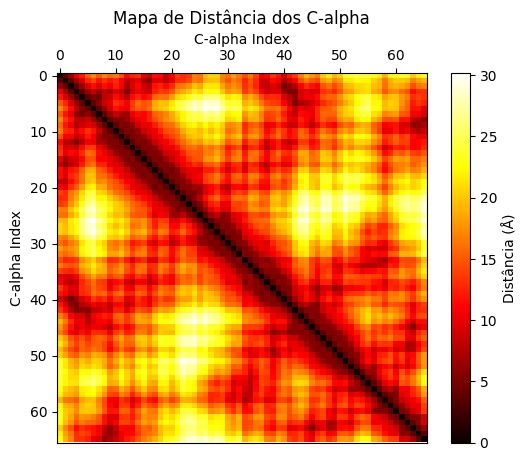

In [145]:
''' Criando mapa de distâncias '''

atomArray = chain.internal_coord.atomArray
# Uma das vantagens atomArray é que gerar um gráfico de distância a partir dele requer apenas uma linha de Numpy
# cria um seletor para filtrar apenas os carbonos alpha (necessário p/ próximo gráfico)
atmNameNdx = AtomKey.fields.atm
aaI = chain.internal_coord.atomArrayIndex
CaSelect = [aaI.get(k) for k in aaI.keys() if k.akl[atmNameNdx] == 'CA']
CA_coords = chain.internal_coord.atomArray[CaSelect]

np.linalg.norm(atomArray[:, None, :] - atomArray[None, :, :], axis=-1)

# Criando o mapa de distância dos C-alpha
caDistances = chain.internal_coord.distance_plot(CaSelect)

# Criando a
fig, ax = plt.subplots()
ax.imshow(caDistances, cmap='hot', interpolation='nearest')
# Adicionando título
ax.set_title('Mapa de Distância dos C-alpha')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('C-alpha Index')
ax.set_ylabel('C-alpha Index')

# Adicionando barra de cores
cbar = plt.colorbar(
    ax.imshow(caDistances, cmap='hot', interpolation='nearest')
)
cbar.set_label('Distância (Å)')

# Showing image
plt.show()
# Saving as png and SVG
fig.savefig('ca_distance_map.png', dpi=300)
fig.savefig('ca_distance_map.svg')

### 4.4.2. Recriando mapa de distâncias


In [146]:
from Bio.PDB.ic_rebuild import IC_duplicate

In [147]:
''' Reconstrução de estrutura a partir de distâncias '''


# Cria o gráfico de distância de todos os átomos
# Cria o gráfico de distância de
distances = myCic.distance_plot()
chirality = myCic.dihedral_signs()  # Obtem os sinais dos ângulos diedros

# Criação de uma estrutura 'vazia', pois copia apenas a estrutura hierárquica, não os valores
chain2 = IC_duplicate(chain)[0]['A']
cic2 = chain2.internal_coord
cic2.atomArray = np.zeros((cic2.AAsiz, 4), dtype=np.float64)
cic2.dihedraAngle[:] = 0.0
cic2.hedraAngle[:] = 0.0
cic2.hedraL12[:] = 0.0
cic2.hedraL23[:] = 0.0
# Fixando a posição inicial no espaço

# Fixando a posição inicial no espaço
# Converte distâncias em coordenadas internas
cic2.copy_initNCaCs(chain.internal_coord)
# Extraindo distâncias locais
cic2.distplot_to_dh_arrays(distances,  chirality)
# Converte distâncias em coordenadas internas
cic2.distance_to_internal_coordinates()
chain2.internal_to_atom_coordinates()  # Reconstrói XYZ
# Verificação final: se o resultado for 'True' é porque deu certo
near_coord = np.allclose(cic2.atomArray, myCic.atomArray)

print(f'Coordenadas reconstruídas próximas das originais? {near_coord}')
# True

Coordenadas reconstruídas próximas das originais? True


In [148]:
''' Sobreposição de resíduos e suas vizinhanças '''

# Sobrepor todos os pares phe-phe - uma solução rápida apenas para demonstrar o conceito

cic = chain.internal_coord
resNameNdx = AtomKey.fields.resname
aaNdx = cic.atomArrayIndex

# Selecionando apenas os átomos da PHE
pheAtomSelect = [
    aaNdx.get(k)
    for k in aaNdx.keys()
    if k.akl[resNameNdx] == 'F'
]

# Copiando as coordenadas
aaF = cic.atomArray[pheAtomSelect]

# Loop sobre resíduos
atom_table_msg = ''
for ric in cic.ordered_aa_ic_list:
    if ric.lc == 'F':  # Filtra apenas PHE
        chi1 = ric.pick_angle('chi1')  # Escolhendo o diedro χ1
        cst = np.transpose(chi1.cst)  # Matriz de transformação
        cic.atomArray[pheAtomSelect] = aaF.dot(cst)  # Aplicando transformação
        for res in chain.get_residues():  # Imprimindo no novo espaço
            if res.resname in ['PHE']:
                atom_table_msg += f'{res.internal_coord.pdb_residue_string()}\n'
        cic.atomArray[pheAtomSelect] = aaF  # Restaurando

print(f'Átomos de PHE sobrepostos:\n{atom_table_msg[:250]}')

Átomos de PHE sobrepostos:
ATOM     81 N    PHE A 161       1.366   0.000  -0.519  1.00 13.37           N
ATOM     82 CA   PHE A 161       0.000   0.000  -0.000  1.00 12.78           C
ATOM     83 C    PHE A 161      -0.872   1.144  -0.527  1.00 12.00           C
ATOM     84 O


#### Impressão 3D de estruturas de proteínas


In [149]:
from Bio.PDB.internal_coords import IC_Residue
from Bio.PDB.SCADIO import write_SCAD

In [150]:
''' Impressão 3D de proteínas usando OpenSCAD '''

# Filtra apenas backbone
IC_Residue.accept_atoms = IC_Residue.accept_backbone
# Ajusta limite de quebra de cadeia
IC_Chain.MaxPeptideBond = 4.0
chain.internal_coord = None
# Gera o arquivo OpenSCAD
write_SCAD(chain, 'myChain.scad', scale=10.0)
print('Arquivo myChain.scad criado!')

Arquivo myChain.scad criado!
